In [278]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study4.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
outputdirCleaned = os.path.join(topdir, f'data/{study}/Cleaned')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_stripes', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'cogpro_predict', 'cogpro_explain', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'stripes_low', 'stripes_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'stripes_discrete_slider.response', 'stripes_direction_slider.response', 'stripes_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_stripes', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'cogpro_predict', 'cogpro_explain', 'relevant_dim', 'irrelevant_

Data Processing (fix string representations of lists)

In [279]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_stripes', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



In [283]:
#for entry in df_combined['feedback']:
#   print(entry)

Sanity Checks

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/942694789.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/942694789.py:26: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


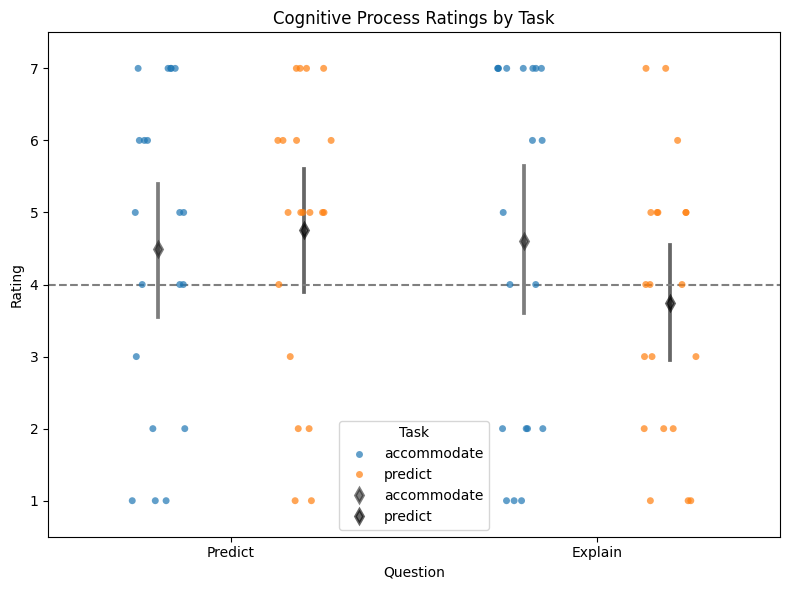

In [280]:

# long format for plotting
df_cogpro_long = df_combined.melt(
    id_vars=['participant', 'task'],
    value_vars=['cogpro_predict', 'cogpro_explain'],
    var_name='question',
    value_name='rating'
)

df_cogpro_long['question'] = df_cogpro_long['question'].replace({
    'cogpro_predict': 'Predict',
    'cogpro_explain': 'Explain'
})

plt.figure(figsize=(8,6))

sns.stripplot(
    data=df_cogpro_long,
    x='question',
    y='rating',
    hue='task',
    dodge=True,
    jitter=.15,
    alpha=.7
)

sns.pointplot(
    data=df_cogpro_long,
    x='question',
    y='rating',
    hue='task',
    dodge=.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.6
)

plt.ylim(.5, 7.5)
plt.axhline(4, color='gray', linestyle='--')
plt.title('Cognitive Process Ratings by Task')
plt.ylabel('Rating')
plt.xlabel('Question')
plt.legend(title='Task')
plt.tight_layout()

plt.savefig(os.path.join(outputdir, 'CogProRatingsByTask.png'), dpi=300)
plt.show()

In [245]:
#Look at fertility score in training by participant/category in accomodate task
df = df_accommodate[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high        7.463235
1      low        3.544118


In [246]:
#Look at fertility score in training by participant/category in predict task
df = df_predict[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high        7.388889
1      low        3.541667


In [247]:
#Overall means by category in accommodate task (participant responses)
df = df_accommodate[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high          6.617647
1      low          5.470588


In [248]:
#Overall means by actual testing category in prediction task
df = df_predict[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high          6.111111
1      low          5.305556


In [249]:
df_combined.groupby('irrelevant_dim')['feet_high'].value_counts() #Should be perfectly equal (or roughly equal after dropping participants)


irrelevant_dim  feet_high
feet            C            10
                F             8
stripes         F             9
                C             8
Name: count, dtype: int64

Timing

task
accommodate    592.901935
predict        478.403156
Name: trial_stop_time, dtype: float64


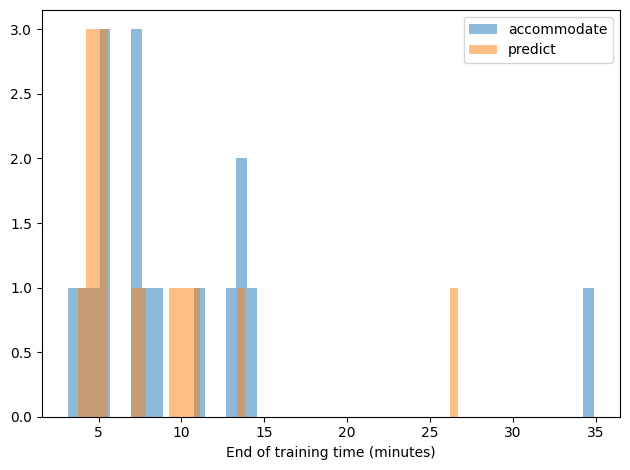

In [250]:
#Look at average time across task
df_combined['trial_stop_time'].describe()
avg_time = df_combined.groupby(['task'])['trial_stop_time'].mean()
print(avg_time)

for task, subdf in df_combined.groupby('task'):
    plt.hist(
        subdf['trial_stop_time']/60,
        bins=50,
        alpha=0.5,
        label=task
    )

plt.xlabel('End of training time (minutes)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure1TrialStopTimeByTask.png'))
plt.show()


**Primary Analysis #1**

Part 1: Model Parameter Score Complexity across conditions

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

participant_rows = []

for _, row in df_combined.iterrows():
    feet_yes = 1 if str(row['feet_discrete_slider.response']).strip() == 'Yes' else 0
    stripes_yes = 1 if str(row['stripes_discrete_slider.response']).strip() == 'Yes' else 0

    model_param_score = feet_yes + stripes_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],

        'relevant_dim': row['relevant_dim'],
        'irrelevant_dim': row['irrelevant_dim'],

        'feet_high': row['feet_high'],
        'stripes_high': row['stripes_high'],
        'feet_low': row['feet_low'],
        'stripes_low': row['stripes_low'],

        'feet_discrete_slider.response': row['feet_discrete_slider.response'],
        'stripes_discrete_slider.response': row['stripes_discrete_slider.response'],

        'feet_reported_relevant': feet_yes,
        'stripes_reported_relevant': stripes_yes,
        'cogpro_explain': row['cogpro_explain'],
        'cogpro_predict': row['cogpro_predict']

        # overfit = selected both dimensions
        'overfit': model_param_score == 2
    })

df_params = pd.DataFrame(participant_rows)

contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit      False  True 
task                     
accommodate     11      9
predict         15      5
Chi-square = 0.989
df = 1
p-value = 0.3200


In [252]:
import pandas as pd

#Look at average ratings by model_param_score in predict task, by category

# Keep only predict participantss from df_params, with model_param_score
predict_params = df_params.loc[
    df_params['task'] == 'predict',
    ['conditionOrder', 'model_param_score']
].copy()

# Keep rating data
df_pred = df_predict[['conditionOrder', 'testing_categories', 'testing_responses']].copy()

# Explode testing categories/responses into long 
df_pred_long = (
    df_pred
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category',
                     'testing_responses': 'rating'})
)

# Merge model_param_score onto the prediction ratings using conditionOrder
df_merged = df_pred_long.merge(
    predict_params,
    on='conditionOrder',
    how='inner'
)

# Make rating numeric
df_merged['rating'] = pd.to_numeric(df_merged['rating'], errors='coerce')

# Keep only model_param_score 0, 1, 2
df_merged = df_merged[df_merged['model_param_score'].isin([0, 1, 2])]

# Average ratings by model_param_score and category
avg_rating = (
    df_merged
    .groupby(['model_param_score', 'category'], as_index=False)['rating']
    .mean()
    .sort_values(['model_param_score', 'category'])
)

print(avg_rating)

   model_param_score category    rating
0                  0     high  5.666667
1                  0      low  5.750000
2                  1     high  6.375000
3                  1      low  5.125000
4                  2     high  6.250000
5                  2      low  5.000000


          task irrelevant_dim      mean  sum  count  overfit_percent
0  accommodate           feet  0.444444    4      9        44.444444
1  accommodate        stripes  0.375000    3      8        37.500000
2      predict           feet  0.222222    2      9        22.222222
3      predict        stripes  0.222222    2      9        22.222222


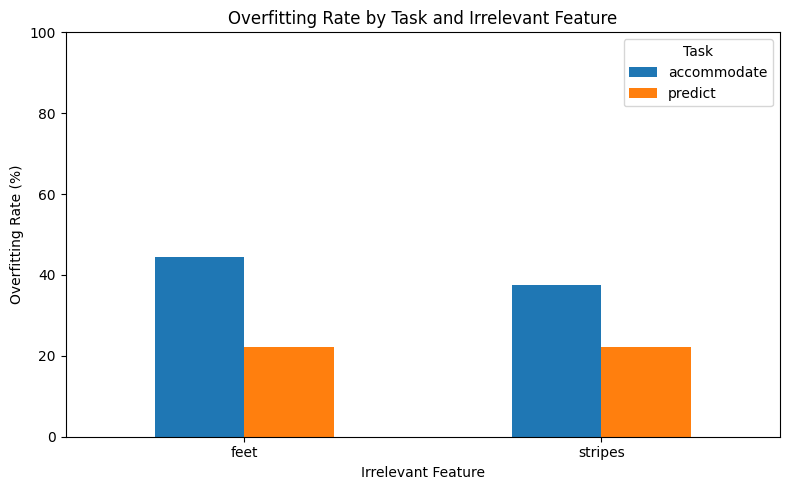

In [253]:
import pandas as pd
import matplotlib.pyplot as plt

# Overfitting rate by task and irrelevant feature
overfit_summary = (
    df_params
    .groupby(['task', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

# Convert mean proportion to percent
overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100

print(overfit_summary)

#Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Pivot for plot
plot_data = overfit_summary.pivot(
    index='irrelevant_dim',
    columns='task',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Task and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='Task')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure2OverfittingRateByTask.png'))
plt.show()

  explain_group irrelevant_dim      mean  sum  count  overfit_percent
0  High explain           feet  0.454545    5     11        45.454545
1  High explain        stripes  0.461538    6     13        46.153846
2   Low explain           feet  0.222222    2      9        22.222222
3   Low explain        stripes  0.142857    1      7        14.285714


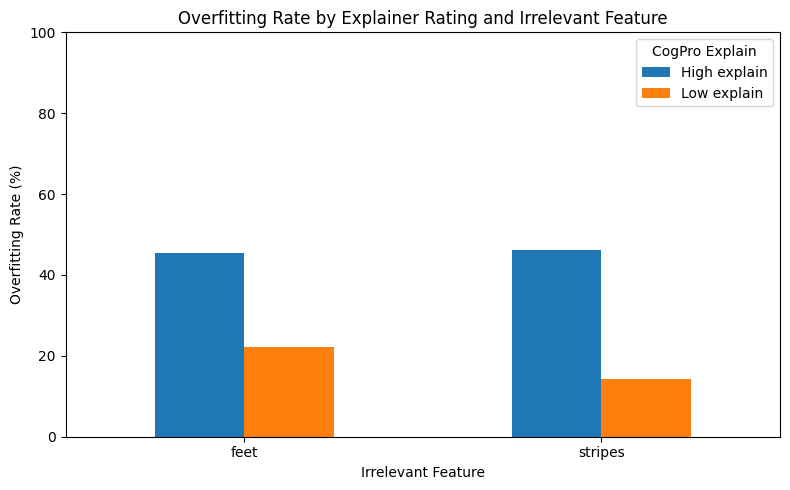

In [289]:
# High/low explainer rating
df_params['explain_group'] = np.where(
    df_params['cogpro_explain'] >= 4,
    'High explain',
    'Low explain'
)

# Overfitting rate by explain group and irrelevant feature
overfit_explain_summary = (
    df_params
    .groupby(['explain_group', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_explain_summary['overfit_percent'] = overfit_explain_summary['mean'] * 100

print(overfit_explain_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = overfit_explain_summary.pivot(
    index='irrelevant_dim',
    columns='explain_group',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Explainer Rating and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='CogPro Explain')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'OverfittingRateByCogProExplainanddim.png'), dpi=300)
plt.show()

  explain_group         task      mean  sum  count  overfit_percent
0  High explain  accommodate  0.538462    7     13        53.846154
1  High explain      predict  0.363636    4     11        36.363636
2   Low explain  accommodate  0.285714    2      7        28.571429
3   Low explain      predict  0.111111    1      9        11.111111


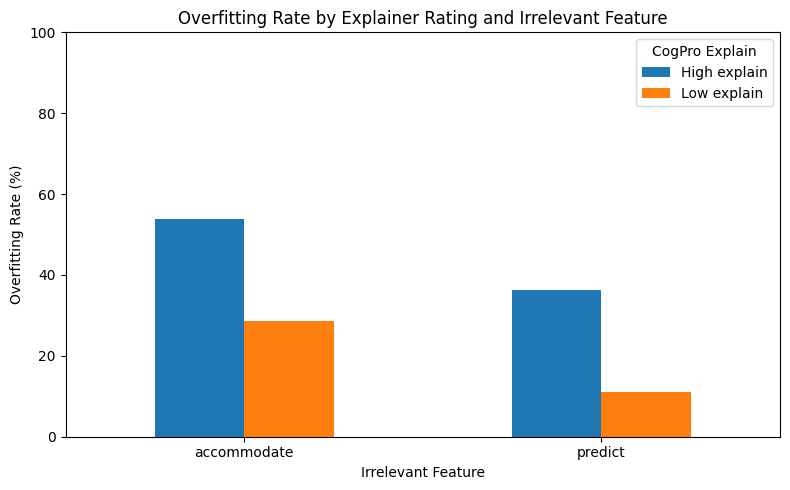

In [288]:
# High/low explainer rating
df_params['explain_group'] = np.where(
    df_params['cogpro_explain'] >= 4,
    'High explain',
    'Low explain'
)

# Overfitting rate by explain group and irrelevant feature
overfit_explain_summary = (
    df_params
    .groupby(['explain_group', 'task'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_explain_summary['overfit_percent'] = overfit_explain_summary['mean'] * 100

print(overfit_explain_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = overfit_explain_summary.pivot(
    index='task',
    columns='explain_group',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Explainer Rating and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='CogPro Explain')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'OverfittingRateByCogProExplainandtask.png'), dpi=300)
plt.show()

In [304]:
# High/low explainer rating
df_params['predict_group'] = np.where(
    df_params['cogpro_predict'] >= 4,
    'High predict',
    'Low predict'
)

# Overfitting rate by explain group and irrelevant feature
overfit_predict_summary = (
    df_params
    .groupby(['predict_group', 'task'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_predict_summary['overfit_percent'] = overfit_predict_summary['mean'] * 100

print(overfit_predict_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = overfit_predict_summary.pivot(
    index='task',
    columns='predict_group',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Predictor Rating and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='CogPro Explain')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'OverfittingRateByCogProPredictandtask.png'), dpi=300)
plt.show()

KeyError: 'cogpro_predict'

          task irrelevant_dim      mean  sum  count  \
0  accommodate           feet  0.444444    4      9   
1  accommodate        stripes  0.625000    5      8   
2      predict           feet  0.555556    5      9   
3      predict        stripes  0.666667    6      9   

   percent_reported_irrelevant  
0                    44.444444  
1                    62.500000  
2                    55.555556  
3                    66.666667  


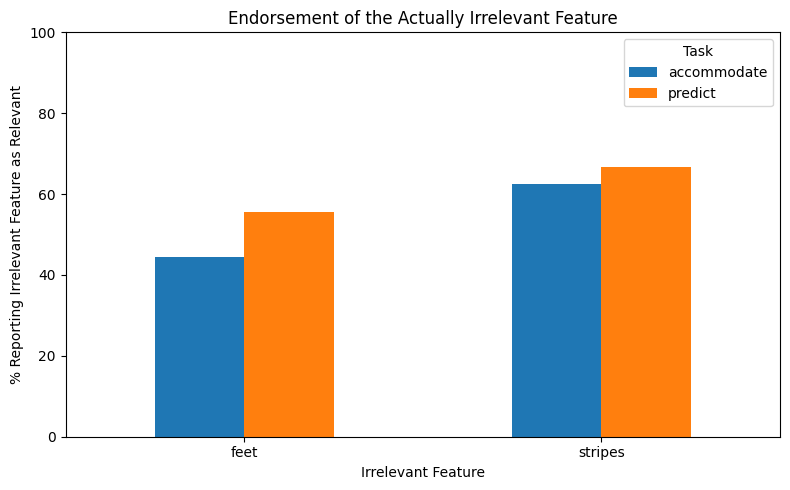

In [254]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Build long version of reported relevance
reported_long = df_params.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'overfit'],
    value_vars=[
        'feet_discrete_slider.response',
        'stripes_discrete_slider.response'
    ],
    var_name='reported_feature',
    value_name='reported_response'
)

# Clean feature names
reported_long['reported_feature'] = (
    reported_long['reported_feature']
    .str.replace('_discrete_slider.response', '', regex=False)
)

# Did participant say this feature mattered?
reported_long['reported_relevant'] = (
    reported_long['reported_response'].astype(str).str.strip().eq('Yes')
).astype(int)

# Is this feature actually irrelevant?
reported_long['is_irrelevant_feature'] = (
    reported_long['reported_feature'] == reported_long['irrelevant_dim']
)

# Keep only the actually irrelevant feature for each participant
irrelevant_reports = reported_long[reported_long['is_irrelevant_feature']].copy()

# Summarize: when feet vs stripes are irrelevant, how often was that irrelevant feature endorsed?
irrelevant_summary = (
    irrelevant_reports
    .groupby(['task', 'irrelevant_dim'])['reported_relevant']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

irrelevant_summary['percent_reported_irrelevant'] = irrelevant_summary['mean'] * 100

print(irrelevant_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = irrelevant_summary.pivot(
    index='irrelevant_dim',
    columns='task',
    values='percent_reported_irrelevant'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Endorsement of the Actually Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('% Reporting Irrelevant Feature as Relevant')
ax.set_ylim(0, 100)
ax.legend(title='Task')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(os.path.join(outputdir, 'IrrelevantFeatureEndorsementByTask.png'))
plt.show()

          task relevant_dim      mean  count    percent
0  accommodate         feet  0.500000      8  50.000000
1  accommodate      stripes  0.555556      9  55.555556
2      predict         feet  0.222222      9  22.222222
3      predict      stripes  0.333333      9  33.333333


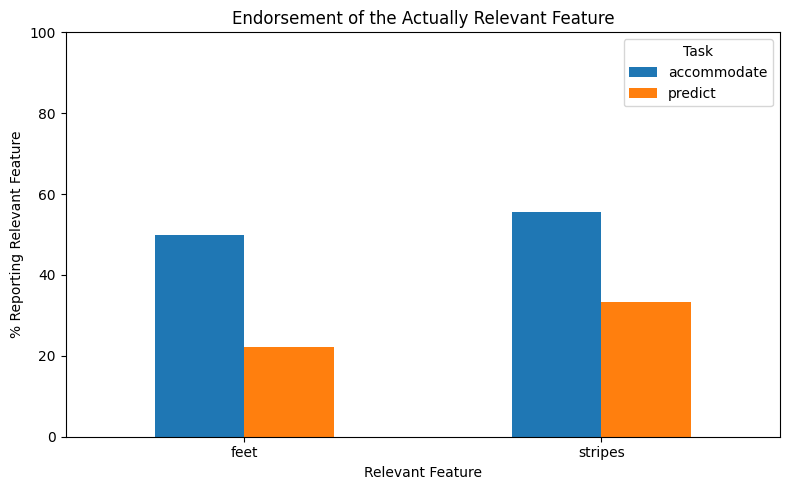

In [255]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Build long format
reported_long = df_params.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim'],
    value_vars=[
        'feet_discrete_slider.response',
        'stripes_discrete_slider.response'
    ],
    var_name='feature',
    value_name='response'
)

# Clean names
reported_long['feature'] = (
    reported_long['feature']
    .str.replace('_discrete_slider.response', '', regex=False)
)

# Binary endorsement
reported_long['reported_relevant'] = (
    reported_long['response'].astype(str).str.strip() == 'Yes'
).astype(int)

# Keep ONLY the actually relevant feature
relevant_reports = reported_long[
    reported_long['feature'] == reported_long['relevant_dim']
].copy()

# Summarize
relevant_summary = (
    relevant_reports
    .groupby(['task', 'relevant_dim'])['reported_relevant']
    .agg(['mean', 'count'])
    .reset_index()
)

relevant_summary['percent'] = relevant_summary['mean'] * 100

print(relevant_summary)
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = relevant_summary.pivot(
    index='relevant_dim',
    columns='task',
    values='percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Endorsement of the Actually Relevant Feature')
ax.set_xlabel('Relevant Feature')
ax.set_ylabel('% Reporting Relevant Feature')
ax.set_ylim(0, 100)
ax.legend(title='Task')

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(os.path.join(outputdir, 'RelevantFeatureEndorsementByTask.png'))
plt.show()


In [256]:
df_params['choice_type'] = df_params.apply(lambda row:
    'both' if (row['feet_reported_relevant'] == 1 and row['stripes_reported_relevant'] == 1)
    else 'feet_only' if row['feet_reported_relevant'] == 1
    else 'stripes_only' if row['stripes_reported_relevant'] == 1
    else 'none',
    axis=1
)

choice_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'choice_type'])
    .size()
    .reset_index(name='count')
)

choice_counts['percent'] = (
    choice_counts['count'] /
    choice_counts.groupby(['task', 'irrelevant_dim'])['count'].transform('sum')
    * 100
)

print(choice_counts)

           task irrelevant_dim   choice_type  count    percent
0   accommodate           feet          both      4  44.444444
1   accommodate           feet          none      4  44.444444
2   accommodate           feet  stripes_only      1  11.111111
3   accommodate        stripes          both      3  37.500000
4   accommodate        stripes     feet_only      1  12.500000
5   accommodate        stripes          none      2  25.000000
6   accommodate        stripes  stripes_only      2  25.000000
7       predict           feet          both      2  22.222222
8       predict           feet     feet_only      3  33.333333
9       predict           feet          none      3  33.333333
10      predict           feet  stripes_only      1  11.111111
11      predict        stripes          both      2  22.222222
12      predict        stripes          none      3  33.333333
13      predict        stripes  stripes_only      4  44.444444


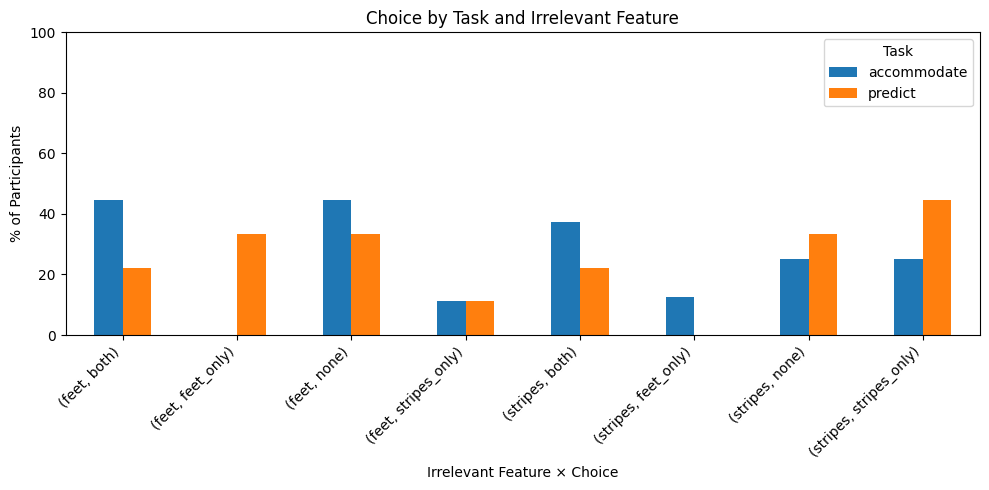

In [257]:
import matplotlib.pyplot as plt
import os

plot_data = choice_counts.pivot_table(
    index=['irrelevant_dim', 'choice_type'],
    columns='task',
    values='percent',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 5))

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Choice by Task and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature × Choice')
ax.set_ylabel('% of Participants')
ax.set_ylim(0, 100)
ax.legend(title='Task')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'ChoiceTypeByTaskAndIrrelevantFeature.png'))
plt.show()

In [258]:
subset = df_combined[
    (df_combined['irrelevant_dim'] == 'feet')
].copy()

# Print values separately by task
for task, df_sub in subset.groupby('task'):
    vals = df_sub['feet_continuous_slider.response'].dropna().tolist()
    
    print(f"\nTask: {task}")
    print(f"N = {len(vals)}")
    print("Values:", sorted(vals))


Task: accommodate
N = 4
Values: [1.0, 3.0, 3.0, 5.0]

Task: predict
N = 5
Values: [3.0, 3.0, 3.0, 5.0, 6.0]


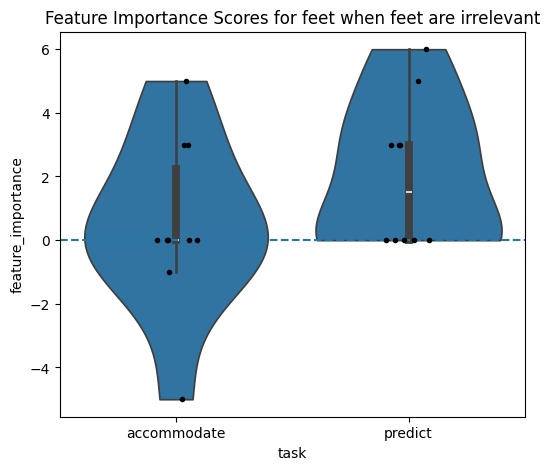

In [259]:
fig, ax = plt.subplots(figsize=(6, 5))

# Violin
sns.violinplot(
    data=feet_irrelevant,
    x='task',
    y='feature_importance',
    inner='box',
    cut=0,
    ax=ax
)

# Raw points (this is the truth)
sns.stripplot(
    data=feet_irrelevant,
    x='task',
    y='feature_importance',
    color='black',
    size=4,
    jitter=0.1,
    ax=ax
)

ax.axhline(0, linestyle='--')

plt.title('Feature Importance Scores for feet when feet are irrelevant')
plt.show()

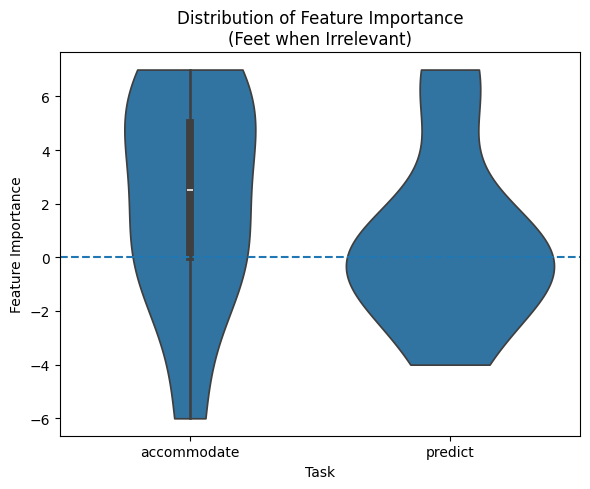

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(6, 5))

sns.violinplot(
    data=feet_irrelevant,
    x='task',
    y='feature_importance',
    inner='box',   # shows median + IQR
    cut=0,
    ax=ax
) 

ax.axhline(0, linestyle='--')  # neutral point

ax.set_title('Distribution of Feature Importance\n(Feet when Irrelevant)')
ax.set_xlabel('Task')
ax.set_ylabel('Feature Importance')

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeetIrrelevant_Violin.png'))
plt.show()

In [186]:
feet_irrelevant_nonzero = (
    feet_irrelevant
    .assign(
        nonzero=lambda x: x['feature_importance'] != 0,
        positive=lambda x: x['feature_importance'] > 0,
        abs_importance=lambda x: x['feature_importance'].abs()
    )
    .groupby('task')
    .agg(
        n=('feature_importance', 'count'),
        mean_importance=('feature_importance', 'mean'),
        mean_abs_importance=('abs_importance', 'mean'),
        prop_nonzero=('nonzero', 'mean'),
        prop_positive=('positive', 'mean')
    )
    .reset_index()
)

print(feet_irrelevant_nonzero)

          task   n  mean_importance  mean_abs_importance  prop_nonzero  \
0  accommodate  10              0.5                  1.7           0.5   
1      predict  10              2.0                  2.0           0.5   

   prop_positive  
0            0.3  
1            0.5  


In [86]:
# Merge participant-level overfit status onto trial/feature-level data
feet_irrelevant_with_overfit = feet_irrelevant.merge(
    df_params[['participant', 'task', 'overfit']],
    on=['participant', 'task'],
    how='left'
)

summary_by_overfit = (
    feet_irrelevant_with_overfit
    .assign(abs_importance=lambda x: x['feature_importance'].abs())
    .groupby(['task', 'overfit'])
    .agg(
        n=('feature_importance', 'count'),
        mean_importance=('feature_importance', 'mean'),
        mean_abs_importance=('abs_importance', 'mean'),
        prop_nonzero=('feature_importance', lambda x: (x != 0).mean()),
        prop_positive=('feature_importance', lambda x: (x > 0).mean())
    )
    .reset_index()
)

print(summary_by_overfit)

          task  overfit  n  mean_importance  mean_abs_importance  \
0  accommodate    False  5             0.00                 0.00   
1  accommodate     True  5             1.00                 3.40   
2      predict    False  8             1.75                 1.75   
3      predict     True  2             3.00                 3.00   

   prop_nonzero  prop_positive  
0         0.000          0.000  
1         1.000          0.600  
2         0.375          0.375  
3         1.000          1.000  


<Axes: xlabel='feature_importance', ylabel='Count'>

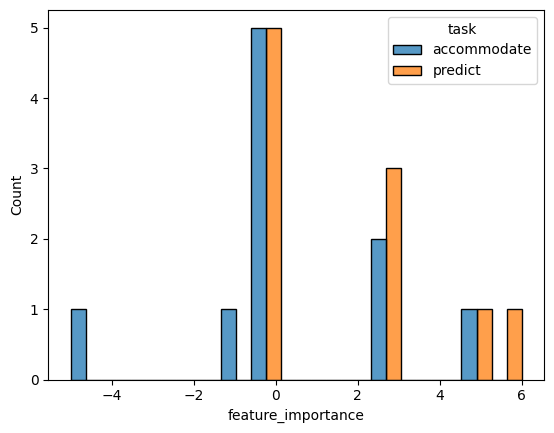

In [187]:
sns.histplot(
    data=feet_irrelevant,
    x='feature_importance',
    hue='task',
    bins=15,
    kde=False,
    multiple='dodge'
)

In [88]:
# Feet is irrelevant → the other feature is relevant
feet_irrelevant = df_long[
    (df_long['irrelevant_dim'] == 'feet') &
    (df_long['feature_relevance'] == 'relevant')
].copy()

relevant_summary = (
    feet_irrelevant
    .groupby('task')['feature_importance']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reset_index()
)

print(relevant_summary)

# Get both relevant and irrelevant for predictors when feet is irrelevant
predictors_feet_case = df_long[
    (df_long['irrelevant_dim'] == 'feet') &
    (df_long['task'] == 'predict')
]

comparison = (
    predictors_feet_case
    .groupby('feature_relevance')['feature_importance']
    .agg(['count', 'mean', 'median', 'std'])
    .reset_index()
)

print(comparison)
pivot = (
    predictors_feet_case
    .pivot_table(
        index='participant',
        columns='feature_relevance',
        values='feature_importance'
    )
    .dropna()
)

pivot['relevant_minus_irrelevant'] = pivot['relevant'] - pivot['irrelevant']

print(pivot['relevant_minus_irrelevant'].describe())

          task  count  mean  median       std  min  max
0  accommodate     10   2.2     2.5  4.049691 -6.0  7.0
1      predict     10   0.7     0.0  3.335000 -4.0  7.0
  feature_relevance  count  mean  median       std
0        irrelevant     10   2.0     1.5  2.309401
1          relevant     10   0.7     0.0  3.335000
count    10.000000
mean     -1.300000
std       4.854551
min      -7.000000
25%      -5.000000
50%      -1.500000
75%       0.000000
max       7.000000
Name: relevant_minus_irrelevant, dtype: float64


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/1802885703.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('feature_relevance')['feature_importance']
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/1802885703.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


          task      mean  sum  count  overfit_percent    study
0  accommodate  0.411765    7     17        41.176471  Study 3
1      predict  0.222222    4     18        22.222222  Study 3


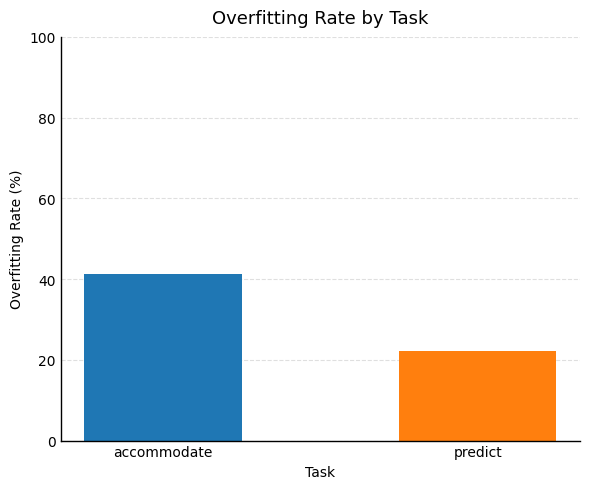

In [260]:
import pandas as pd
import matplotlib.pyplot as plt

# Overall overfitting rate by task
overfit_summary = (
    df_params
    .groupby('task')['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100
overfit_summary['study'] = 'Study 3'
save_path = os.path.join(outputdirCombined, "overfit_summary_study3.csv")
overfit_summary.to_csv(save_path, index=False)

print(overfit_summary)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

colors = ['#1f77b4', '#ff7f0e']

bars = ax.bar(
    overfit_summary['task'],
    overfit_summary['overfit_percent'],
    color=colors,
    width=0.5   # thinner bars (default is ~0.8)
)

# --- Clean look ---
# Remove top/right spines (box)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: lighten left/bottom spines
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Labels
ax.set_title('Overfitting Rate by Task', fontsize=13, pad=10)
ax.set_xlabel('Task')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)

# Optional: remove tick marks for cleaner look
ax.tick_params(axis='both', length=0)

plt.tight_layout()
plt.show()

Part 2: Testing distribution of all model parameter scores by task

model_param_score         task irrelevant_dim    0    1    2
0                  accommodate           feet  4.0  1.0  4.0
1                  accommodate        stripes  2.0  3.0  3.0
2                      predict           feet  3.0  4.0  2.0
3                      predict        stripes  3.0  4.0  2.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2493775690.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim', 'model_param_score'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2493775690.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = score_counts.pivot_table(


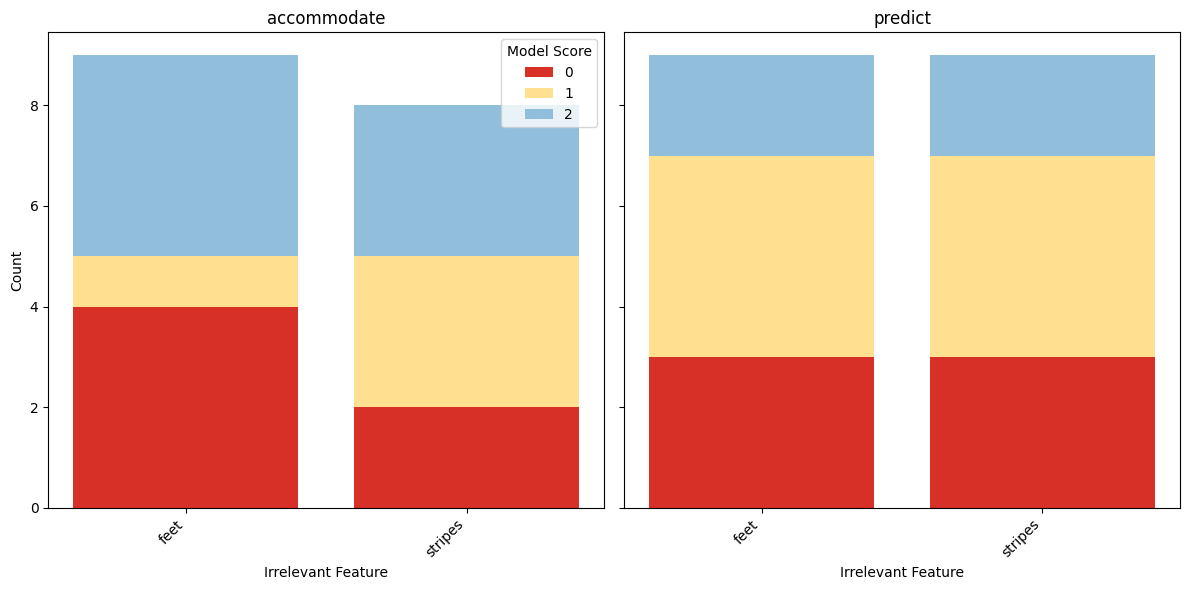

In [261]:
import numpy as np
import matplotlib.pyplot as plt
import os

df_params['task'] = df_params['task'].astype('category')

# Count occurrences of each model_param_score within each task × irrelevant feature
score_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'model_param_score'])
    .size()
    .reset_index(name='count')
)

# Pivot so each score becomes a column
score_pivot = score_counts.pivot_table(
    index=['task', 'irrelevant_dim'],
    columns='model_param_score',
    values='count',
    fill_value=0
).reset_index()

print(score_pivot)

tasks = df_params['task'].cat.categories
buckets = [0, 1, 2]   # now only 3 possible scores with 2 features
colors = ['#d73027', '#fee090', '#91bfdb']  # one color per score

# Create subplots, one per task
fig, axes = plt.subplots(1, len(tasks), figsize=(12, 6), sharey=True)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    # Filter for this task
    task_data = score_pivot[score_pivot['task'] == task].copy()

    x = np.arange(len(task_data))
    bottom = np.zeros(len(task_data))

    for i, b in enumerate(buckets):
        values = task_data[b] if b in task_data.columns else np.zeros(len(task_data))
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=f"{b}" if ax == axes[0] else "",
            color=colors[i]
        )
        bottom += values.values if hasattr(values, "values") else values

    ax.set_xticks(x)
    ax.set_xticklabels(task_data['irrelevant_dim'], rotation=45, ha='right')
    ax.set_title(task)
    ax.set_xlabel("Irrelevant Feature")

axes[0].set_ylabel("Count")
axes[0].legend(title="Model Score")
plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3ModelParamScoreDistributionByTaskAndIrrelevantFeature.png'))
plt.show()

model_param_score  0  1  2
task                      
accommodate        6  4  7
predict            6  8  4
Chi-square = 2.125
df = 2
p-value = 0.3456


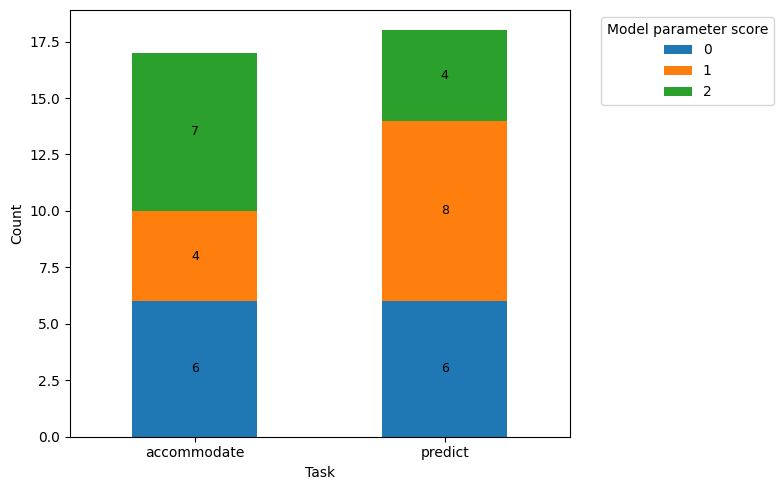

In [262]:
contingency_all = pd.crosstab(
    df_params['task'],
    df_params['model_param_score']
)

print(contingency_all)

chi2, p, dof, expected = chi2_contingency(contingency_all)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

ax = contingency_all.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_xlabel("Task")
ax.set_ylabel("Count")
#ax.set_title("Model Parameter Scores by Task")

# Add numerical labels with the count
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=9
    )
plt.legend(title="Model parameter score", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "Figure2_TaskByModelParamScore_StackedBars.png"),
    dpi=300
)
plt.show()
plt.close()

#Function of condition, wing relevance, and wing direction - the full distribution across that 
#code explanations later


**Primary Analysis #2: Predicting Feature Importance Ratings**

In [290]:
#Create map from short codes to feature descriptions

feet_map = {
    'webbed': 'f',
    'curved/pointy': 'c'
}

stripes_map = {
    'up/right': 'e',
    'up/left': 'w'
}



feature_maps = {
    'feet': feet_map,
    'stripes': stripes_map
}


In [291]:
#Compute feature importance scores

from doctest import debug


def compute_feature_importance_from_df(df):
    """
    Compute numeric feature importance scores(-7 to 7) for each participant,
    based on the saved slider_responses and the feature _high/_low mapping.
    This is computed based on whether a feature was really relevant (positive sign) or irrelevant (negative sign).
    0 = no response or feature was not thought to be relevant
    columns:
      - wings_discrete_slider.response, wings_direction_slider.response, wings_continuous_slider.response
      - color_discrete_slider.response, ...
      - tail_discrete_slider.response, ...
      - wings_high, wings_low, color_high, color_low, tail_high, tail_low
    """
    features = ['feet', 'stripes']
    
    def compute_row_importance(row, feat):
        disc = row[f'{feat}_discrete_slider.response']
        dirc = row[f'{feat}_direction_slider.response']
        cont = row[f'{feat}_continuous_slider.response']

        #If they said a feature wasn't relevant, then importance is 0
        
        if disc == 'No' or pd.isna(disc):
            return 0.0
        
        # Make sure continuous slider value exists, if not, set it to 0
        cont_val = float(cont) if not pd.isna(cont) else 0.0

        # Get mapping from long to short feature name
        mapping = feature_maps.get(feat, {})

        # Normalize strings: strip whitespace, collapse multiple spaces, lower-case
        def normalize_str(s):
            """Strip leading/trailing whitespace and collapse internal multiple spaces."""

            if isinstance(s, str):
                return " ".join(s.split()).lower()
            return ""
        

        #Name of features need to be normalized for comparison using the mapping
        dirc_norm = normalize_str(dirc)

        #Get internal short code for selected feature direction
        internal_dirc = mapping.get(dirc_norm, None)
        

        high_val = normalize_str(row[f'{feat}_high'])
        low_val  = normalize_str(row[f'{feat}_low'])
        

        
        # Debug print statement (make sure mappings look right)
        debug = True
        if debug:
            print('response:', repr(dirc_norm), 'internal:', repr(internal_dirc), 
                'high:', repr(high_val), 'low:', repr(low_val))
            

        #If they correctly selected the high feature, assign positive sign
        if internal_dirc == high_val:
            sign = 1
        #If they incorrectly selected the low feature, assign negative sign
        elif internal_dirc == low_val:
            if debug:
                print('in negative')
            sign = -1
        else:
            if debug:
                print('in empty')
            sign = 0
            cont_val = 0.0

        # Add sign to continuous value
        importance = cont_val * sign

        return importance

    
    # Compute for each feature
    for feat in features:
        df[f'{feat}_importance'] = df.apply(lambda row: compute_row_importance(row, feat), axis=1)
    
    return df

df_combined = compute_feature_importance_from_df(df_combined)
#df_filtered = compute_feature_importance_from_df(df_filtered)
if debug:
    print(df_combined['feet_importance'])

response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'c' low: 'f'
in negative
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'c' low: 'f'
in negative
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curved/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed

In [297]:
import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'stripes_importance',
    'relevant_dim', 'irrelevant_dim', 'feet_high','stripes_high', 'feet_discrete_slider.response',
    'cogpro_explain', 'cogpro_predict'
]

df_long = df_combined[cols_to_keep].copy()

# Melt importance columns
df_long = df_long.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'stripes_high', 'feet_high', 'feet_discrete_slider.response', 'cogpro_explain', 'cogpro_predict'],
    value_vars=['feet_importance', 'stripes_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)

print(df_long.tail(20))

    participant     task relevant_dim irrelevant_dim stripes_high feet_high  \
60           21  predict      stripes           feet            E         C   
61           22  predict      stripes           feet            W         C   
62           23  predict      stripes           feet            W         C   
63           24  predict      stripes           feet            E         C   
64           25  predict      stripes           feet            E         F   
65           26  predict         feet        stripes            W         C   
66           27  predict         feet        stripes            W         F   
67           28  predict      stripes           feet            W         C   
68           29  predict         feet        stripes            E         F   
69           30  predict         feet        stripes            W         F   
70           31  predict         feet        stripes            E         C   
71           32  predict         feet        stripes

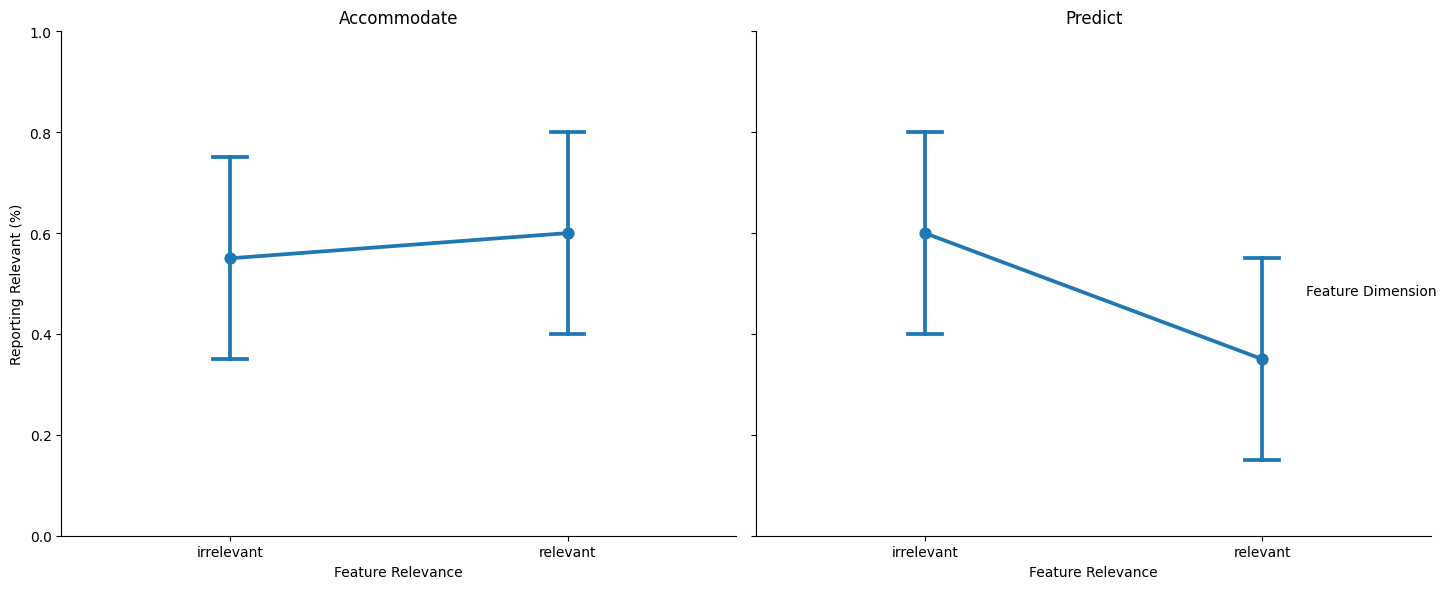

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

df_long['reported_relevant'] = (df_long['feature_importance'] != 0).astype(int)

g = sns.catplot(
    data=df_long,
    x="feature_relevance",
    y="reported_relevant",
    #hue="feature_dimension",
    col="task",
    kind="point",
    dodge=True,
    capsize=0.1,
    markers="o",
    height=6,
    aspect=1.2
)

# y-axis is proportion
g.set(ylim=(0, 1))

g.set_axis_labels("Feature Relevance", "Reporting Relevant (%)")

# nicer subplot titles
for ax in g.axes.flatten():
    ax.set_title(ax.get_title().split(' = ')[-1].capitalize())

g._legend.set_title("Feature Dimension")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure_RelevanceReportingByRelevantFeature.png'))
plt.show()

In [150]:
pd.crosstab(df_long['feature_relevance'], df_long['reported_relevant'])

reported_relevant,0,1
feature_relevance,,
irrelevant,17,23
relevant,21,19


In [151]:
import statsmodels.formula.api as smf

model = smf.logit(
    "reported_relevant ~ task * feature_relevance",
    data=df_long
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.670402
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:      reported_relevant   No. Observations:                   80
Model:                          Logit   Df Residuals:                       76
Method:                           MLE   Df Model:                            3
Date:                Fri, 01 May 2026   Pseudo R-squ.:                 0.03107
Time:                        16:06:59   Log-Likelihood:                -53.632
converged:                       True   LL-Null:                       -55.352
Covariance Type:            nonrobust   LLR p-value:                    0.3287
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                             

FEET — relevant: 20 points
FEET — irrelevant: 20 points
STRIPES — relevant: 20 points
STRIPES — irrelevant: 20 points


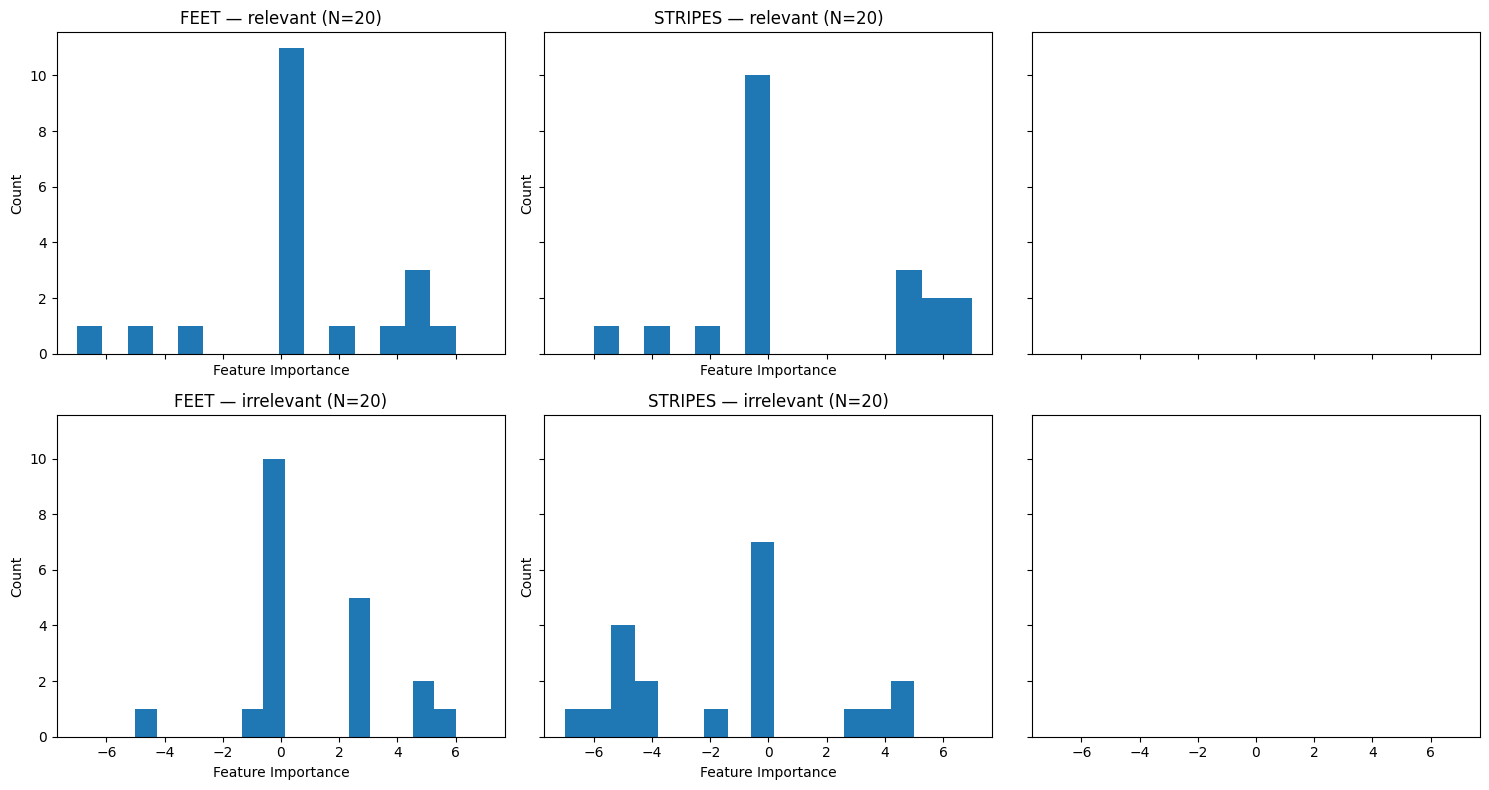

In [293]:
import matplotlib.pyplot as plt

features = ['feet', 'stripes']
relevance_states = ['relevant', 'irrelevant']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):
        
        ax = axes[row, col]
        
        subset = df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ]
        
        # Number of rows in this subset
        n_points = len(subset)
        print(f"{feat.upper()} — {rel}: {n_points} points")
        
        ax.hist(subset['feature_importance'], bins=15, density=False)
        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Feature Importance")
        ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceScoresbyFeature.png'))
plt.show()


In [267]:
means = (
    df_long
    .groupby(['feature_dimension', 'feature_relevance', 'task'])['feature_importance']
    .mean()
    .reset_index(name='mean_feature_importance')
)

print(means)

  feature_dimension feature_relevance         task  mean_feature_importance
0              feet        irrelevant  accommodate                 1.111111
1              feet        irrelevant      predict                 2.222222
2              feet          relevant  accommodate                 1.375000
3              feet          relevant      predict                 0.666667
4           stripes        irrelevant  accommodate                -1.875000
5           stripes        irrelevant      predict                -0.888889
6           stripes          relevant  accommodate                 1.888889
7           stripes          relevant      predict                 0.000000


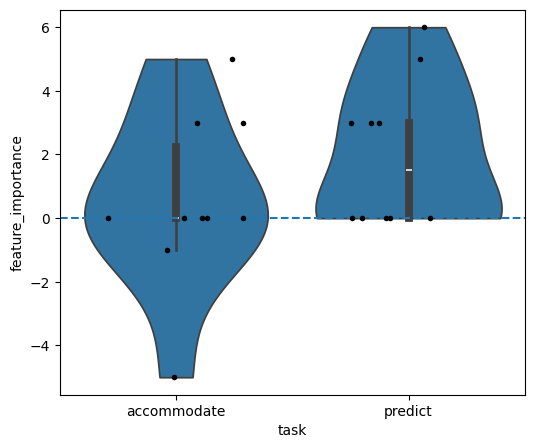

In [294]:
fig, ax = plt.subplots(figsize=(6, 5))

subset = df_long[
    (df_long['feature_dimension'] == 'feet') &
    (df_long['feature_relevance'] == 'irrelevant')
]

# Violin
sns.violinplot(
    data=subset,
    x='task',
    y='feature_importance',
    inner='box',
    cut=0,
    ax=ax
)

# Raw points (truth)
sns.stripplot(
    data=subset,
    x='task',
    y='feature_importance',
    color='black',
    size=4,
    jitter=0.3,
    ax=ax
)

ax.axhline(0, linestyle='--')

plt.show()

In [201]:
# Count per task
counts = subset['task'].value_counts()
print(counts)

task
accommodate    10
predict        10
Name: count, dtype: int64


/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


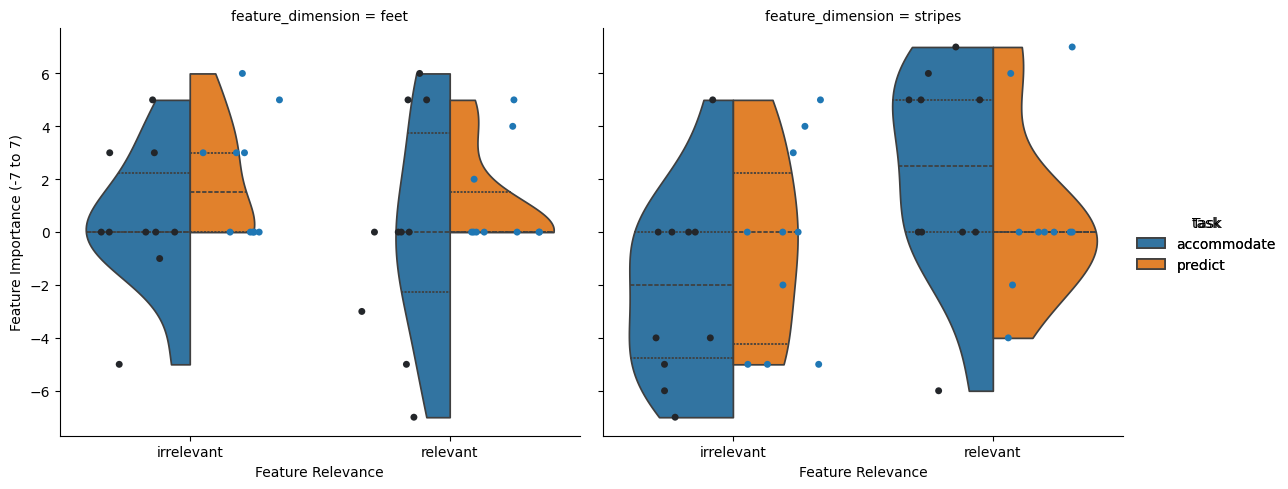

In [295]:
g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    col='feature_dimension',
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    #density_norm='width',   
    #common_norm=False,     
    height=5,
    aspect=1
)

g.map_dataframe(
    sns.stripplot,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=True,
    alpha=1,
    size=5,
    jitter=0.3,
    legend=False
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'Figure4_FeatureImportance_ByTask_Relevance_FacetedByDimension_WithPoints.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/224283789.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/224283789.py:12: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


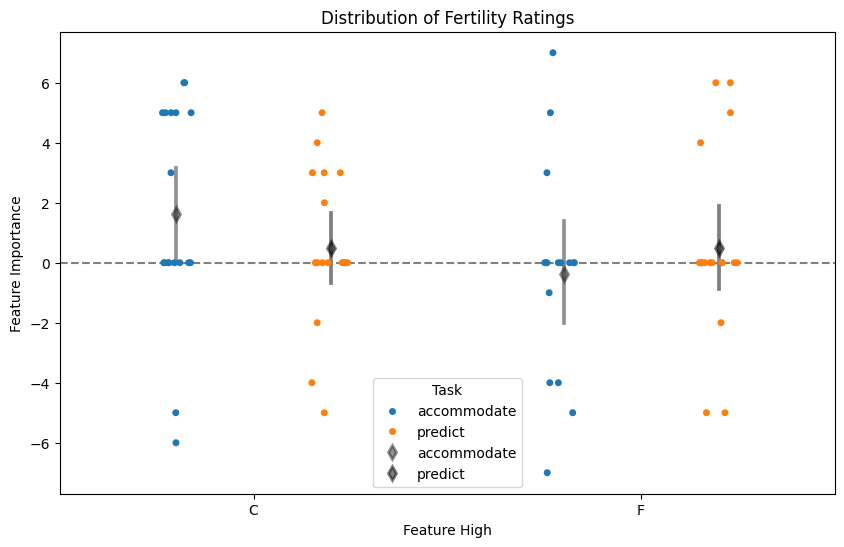

In [270]:

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='feet_high',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='feet_high',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Ratings')
plt.ylabel('Feature Importance')
plt.xlabel('Feature High')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByTaskAndFeetViolin.png'), dpi=300)

plt.show()


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/1259767135.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/1259767135.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


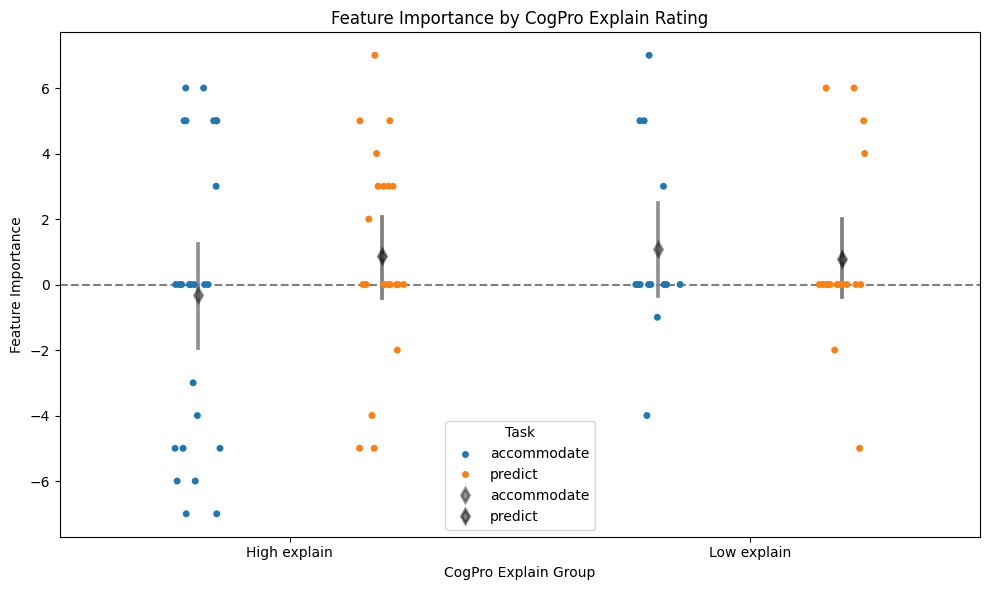

In [298]:
df_long['explain_group'] = np.where(
    df_long['cogpro_explain'] >= 4,
    'High explain',
    'Low explain'
)

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='explain_group',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='explain_group',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.5
)

plt.axhline(0, color='gray', linestyle='--')
plt.title('Feature Importance by CogPro Explain Rating')
plt.ylabel('Feature Importance')
plt.xlabel('CogPro Explain Group')
plt.legend(title='Task')
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByCogProExplain.png'), dpi=300)
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/821713531.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/821713531.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


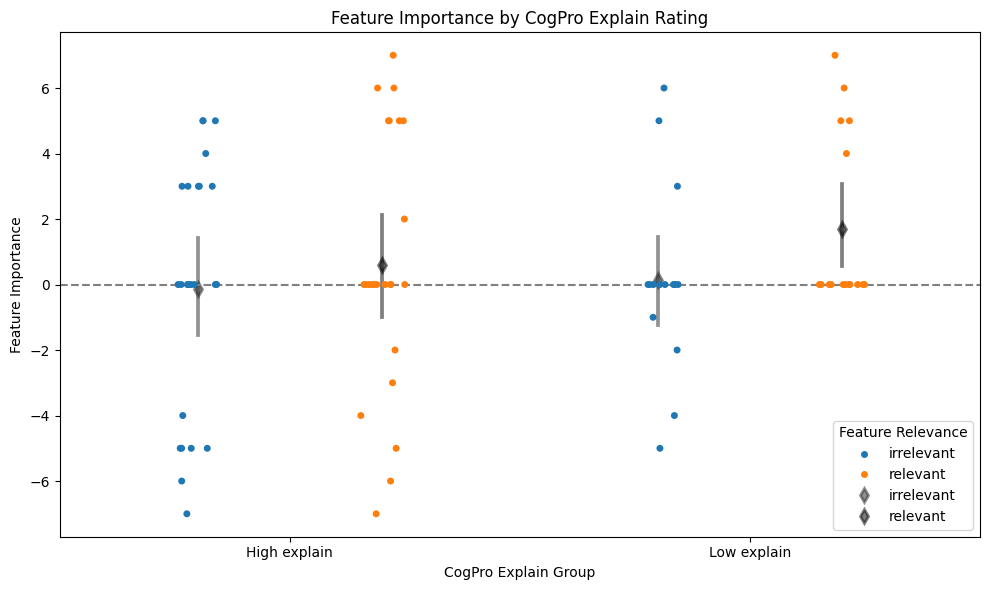

In [300]:
df_long['explain_group'] = np.where(
    df_long['cogpro_explain'] >= 4,
    'High explain',
    'Low explain'
)

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='explain_group',
    y='feature_importance',
    hue='feature_relevance',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='explain_group',
    y='feature_importance',
    hue='feature_relevance',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.5
)

plt.axhline(0, color='gray', linestyle='--')
plt.title('Feature Importance by CogPro Explain Rating')
plt.ylabel('Feature Importance')
plt.xlabel('CogPro Explain Group')
plt.legend(title='Feature Relevance')
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByCogProExplainandRelevance.png'), dpi=300)
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2517680896.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2517680896.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


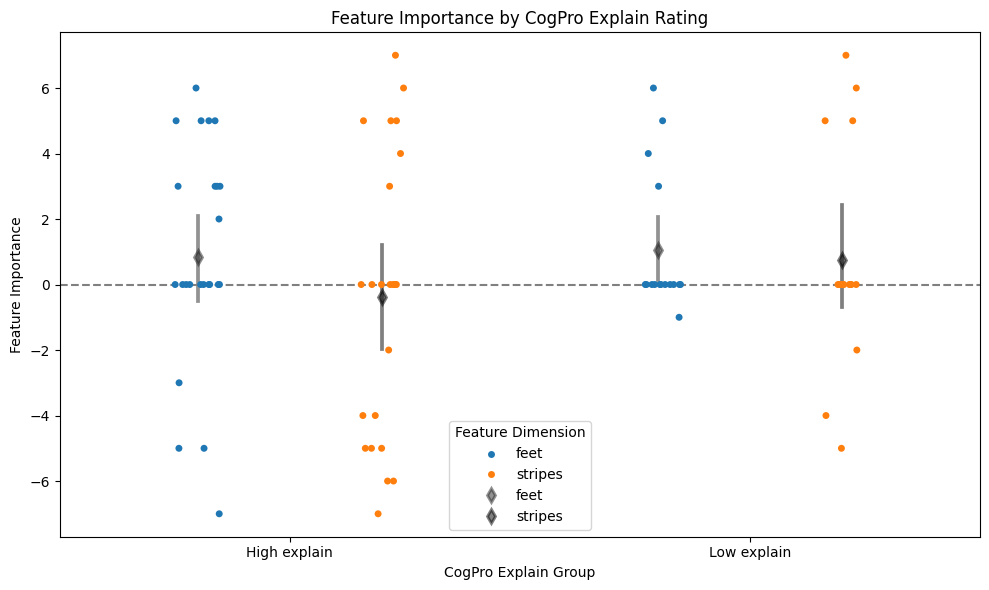

In [302]:
df_long['explain_group'] = np.where(
    df_long['cogpro_explain'] >= 4,
    'High explain',
    'Low explain'
)

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='explain_group',
    y='feature_importance',
    hue='feature_dimension',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='explain_group',
    y='feature_importance',
    hue='feature_dimension',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.5
)

plt.axhline(0, color='gray', linestyle='--')
plt.title('Feature Importance by CogPro Explain Rating')
plt.ylabel('Feature Importance')
plt.xlabel('CogPro Explain Group')
plt.legend(title='Feature Dimension')
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByCogProExplainandDimension.png'), dpi=300)
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/3074420912.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/3074420912.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


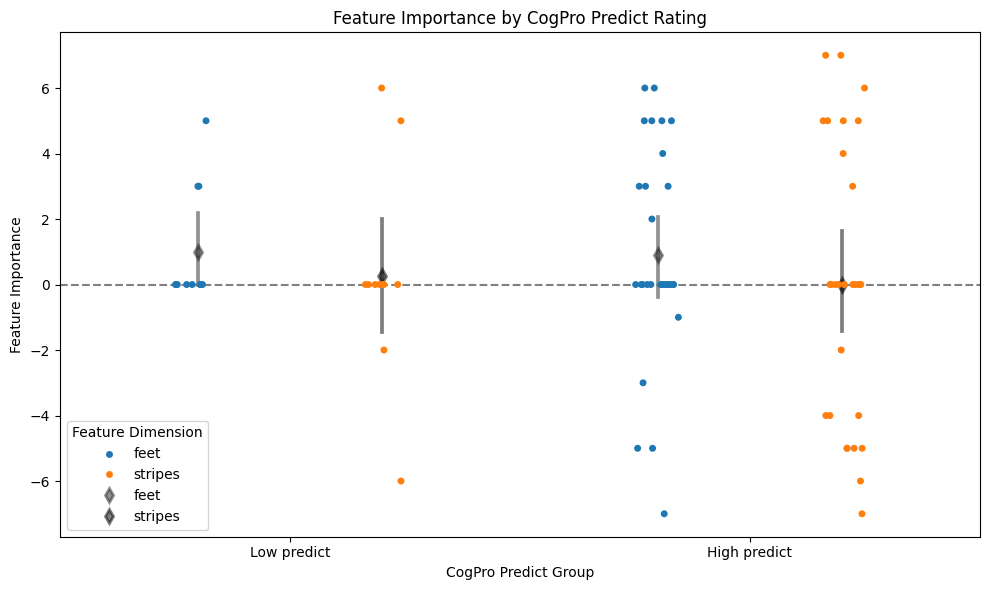

In [303]:
df_long['predict_group'] = np.where(
    df_long['cogpro_predict'] >= 4,
    'High predict',
    'Low predict'
)

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='predict_group',
    y='feature_importance',
    hue='feature_dimension',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='predict_group',
    y='feature_importance',
    hue='feature_dimension',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.5
)

plt.axhline(0, color='gray', linestyle='--')
plt.title('Feature Importance by CogPro Predict Rating')
plt.ylabel('Feature Importance')
plt.xlabel('CogPro Predict Group')
plt.legend(title='Feature Dimension')
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByCogProPredictandDimension.png'), dpi=300)
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/1736575093.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/1736575093.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


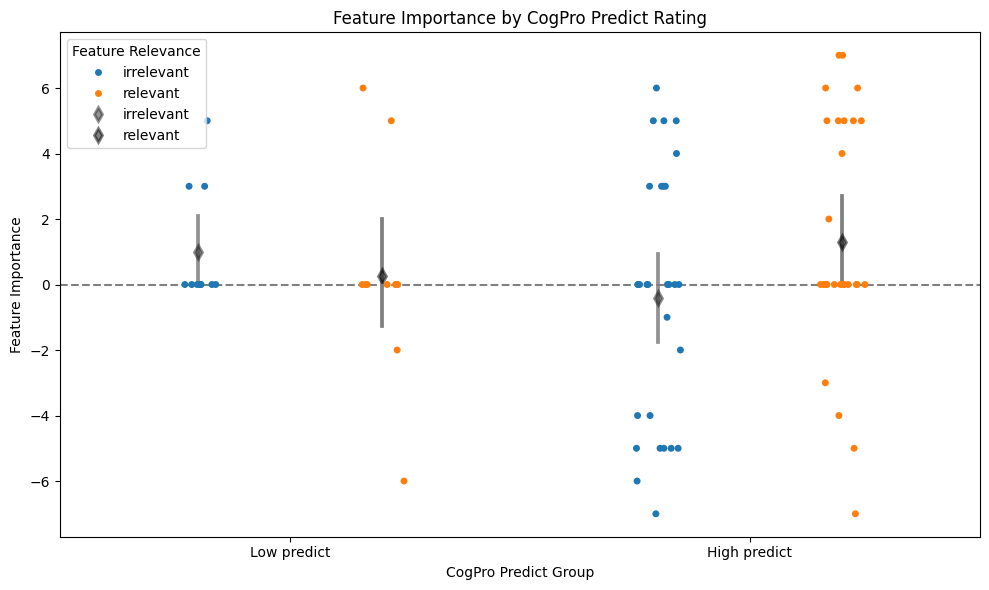

In [301]:
df_long['predict_group'] = np.where(
    df_long['cogpro_predict'] >= 4,
    'High predict',
    'Low predict'
)

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='predict_group',
    y='feature_importance',
    hue='feature_relevance',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='predict_group',
    y='feature_importance',
    hue='feature_relevance',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.5
)

plt.axhline(0, color='gray', linestyle='--')
plt.title('Feature Importance by CogPro Predict Rating')
plt.ylabel('Feature Importance')
plt.xlabel('CogPro Predict Group')
plt.legend(title='Feature Relevance')
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByCogProPredictandRelevance.png'), dpi=300)
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/3117210900.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/3117210900.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


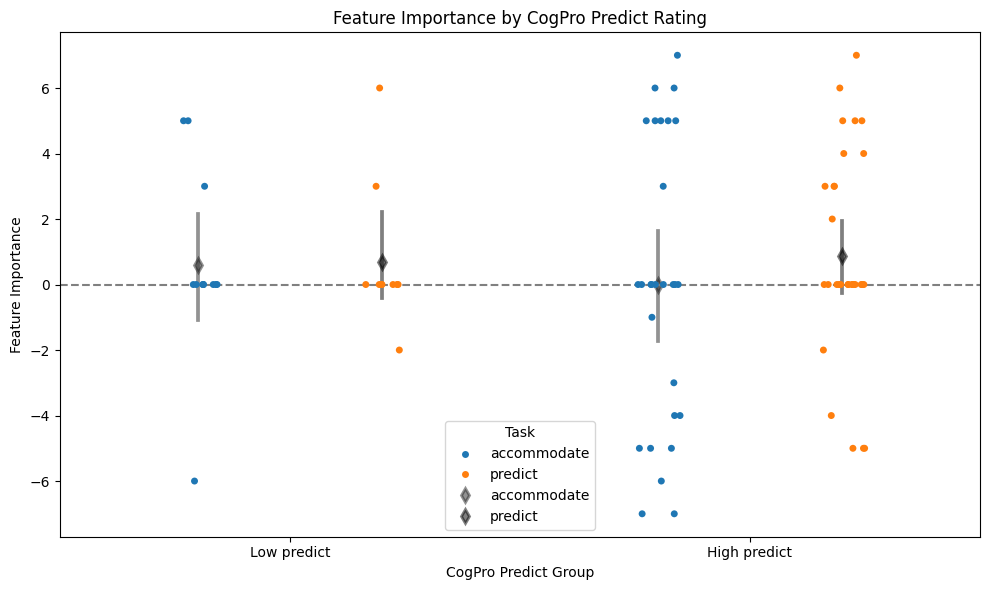

In [299]:
df_long['predict_group'] = np.where(
    df_long['cogpro_predict'] >= 4,
    'High predict',
    'Low predict'
)

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='predict_group',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='predict_group',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.5
)

plt.axhline(0, color='gray', linestyle='--')
plt.title('Feature Importance by CogPro Predict Rating')
plt.ylabel('Feature Importance')
plt.xlabel('CogPro Predict Group')
plt.legend(title='Task')
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByCogProPredict.png'), dpi=300)
plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2304244442.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2304244442.py:12: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


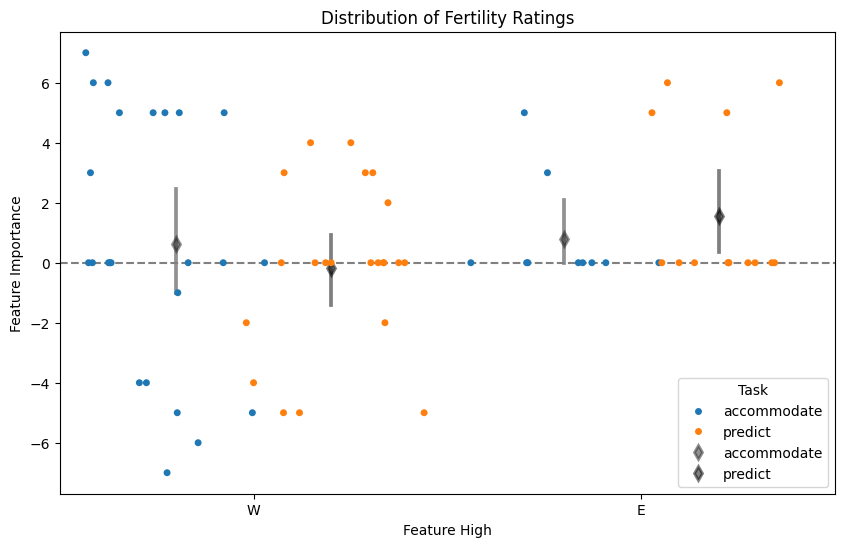

In [271]:

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='stripes_high',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.5,
)

sns.pointplot(
    data=df_long,
    x='stripes_high',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Ratings')
plt.ylabel('Feature Importance')
plt.xlabel('Feature High')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByTaskAndStripeViolin.png'), dpi=300)

plt.show()


In [239]:
quantiles = df_long.groupby(['stripes_high', 'task'])['feature_importance'].quantile(
    [0, .25, .5, .75, 1]
).unstack()

print(quantiles)

                          0.00  0.25  0.50  0.75  1.00
stripes_high task                                     
E            accommodate  -5.0   0.0   0.0  0.00   5.0
             predict       0.0   0.0   0.0  3.75   6.0
W            accommodate  -7.0  -4.0   0.0  5.00   7.0
             predict      -5.0   0.0   0.0  3.00   7.0


In [ ]:
summary = df_long.groupby(['stripes_high', 'task'])['feature_importance'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).reset_index()

print(summary)

#Check E/W counts when u get home
#

  stripes_high         task   n      mean  median       std  min  max
0            E  accommodate  14  0.357143     0.0  2.648865 -5.0  5.0
1            E      predict  14  1.571429     0.0  2.593313  0.0  6.0
2            W  accommodate  26  0.076923     0.0  4.507088 -7.0  7.0
3            W      predict  26  0.423077     0.0  3.100620 -5.0  7.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2558768501.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2558768501.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


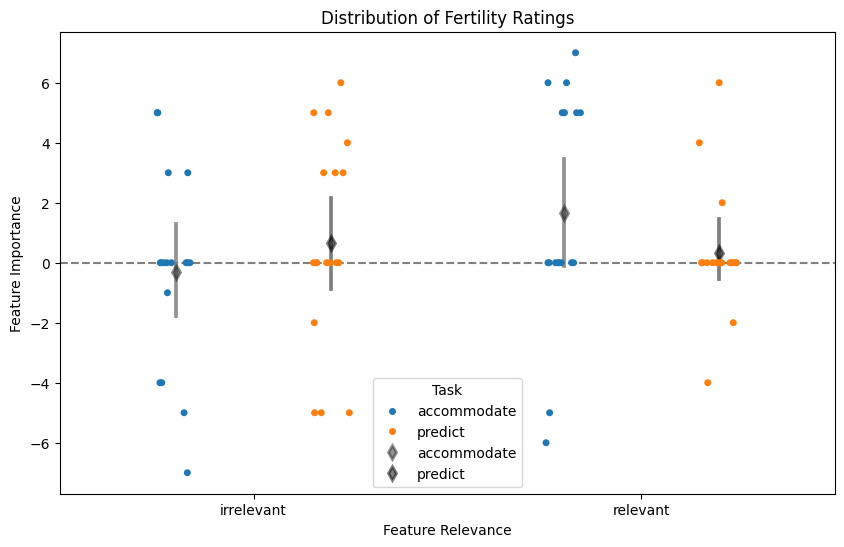

In [272]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.stripplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Ratings')
plt.ylabel('Feature Importance')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove th

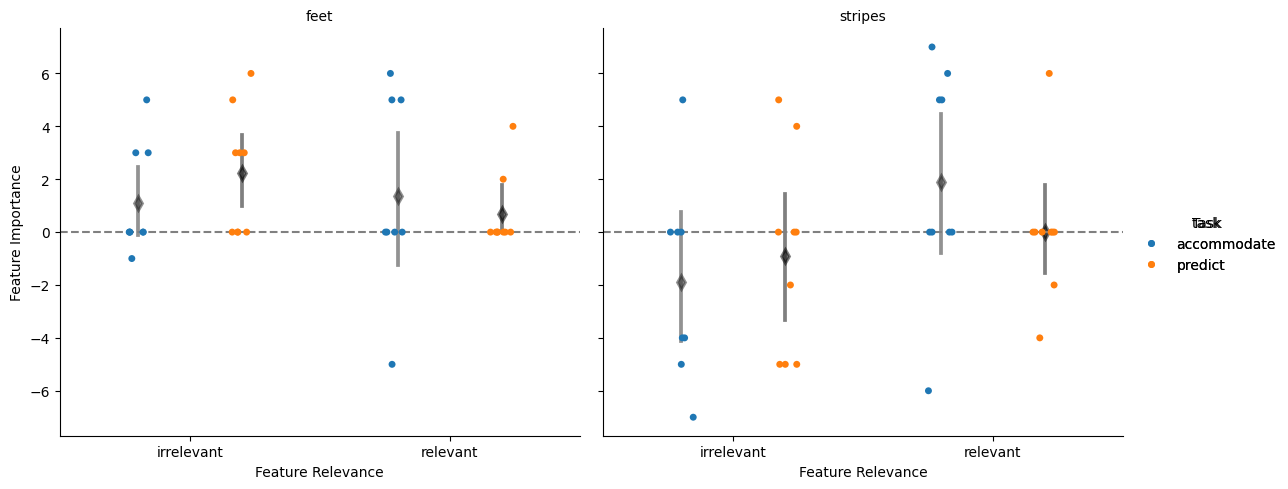

In [273]:
g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    col='feature_dimension',
    kind='strip',
    dodge=True,
    jitter=.1,
    height=5,
    aspect=1
)

g.map_dataframe(
    sns.pointplot,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    legend=False,
    alpha = .5
)

for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--')

g.set_axis_labels('Feature Relevance', 'Feature Importance')
g.set_titles('{col_name}')
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'FeatureImportance_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2558768501.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2558768501.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


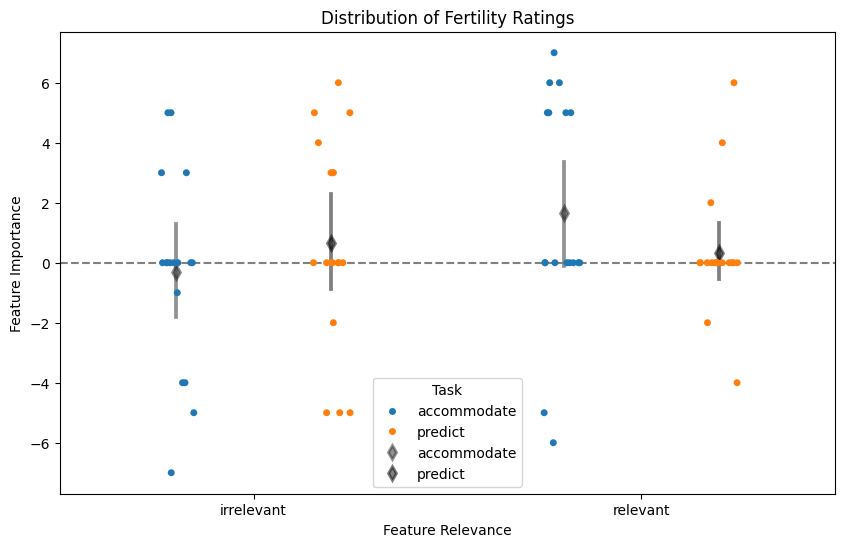

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.stripplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Ratings')
plt.ylabel('Feature Importance')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


In [275]:
pd.crosstab(
    df_params['task'],
    df_params['choice_type'],
    normalize='index'
) * 100

choice_type,both,feet_only,none,stripes_only
task,,,,
accommodate,41.176471,5.882353,35.294118,17.647059
predict,22.222222,16.666667,33.333333,27.777778


In [202]:
print(df_long[['task', 'feature_dimension', 'feature_relevance', 'feature_importance']].head(20))

           task feature_dimension feature_relevance  feature_importance
0   accommodate              feet        irrelevant                 5.0
1   accommodate              feet          relevant                -3.0
2   accommodate              feet          relevant                 6.0
3   accommodate              feet        irrelevant                 3.0
4   accommodate              feet          relevant                 0.0
5   accommodate              feet        irrelevant                 0.0
6   accommodate              feet        irrelevant                 0.0
7   accommodate              feet        irrelevant                 0.0
8   accommodate              feet        irrelevant                -5.0
9   accommodate              feet          relevant                 5.0
10  accommodate              feet          relevant                 5.0
11  accommodate              feet          relevant                -5.0
12  accommodate              feet        irrelevant             

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


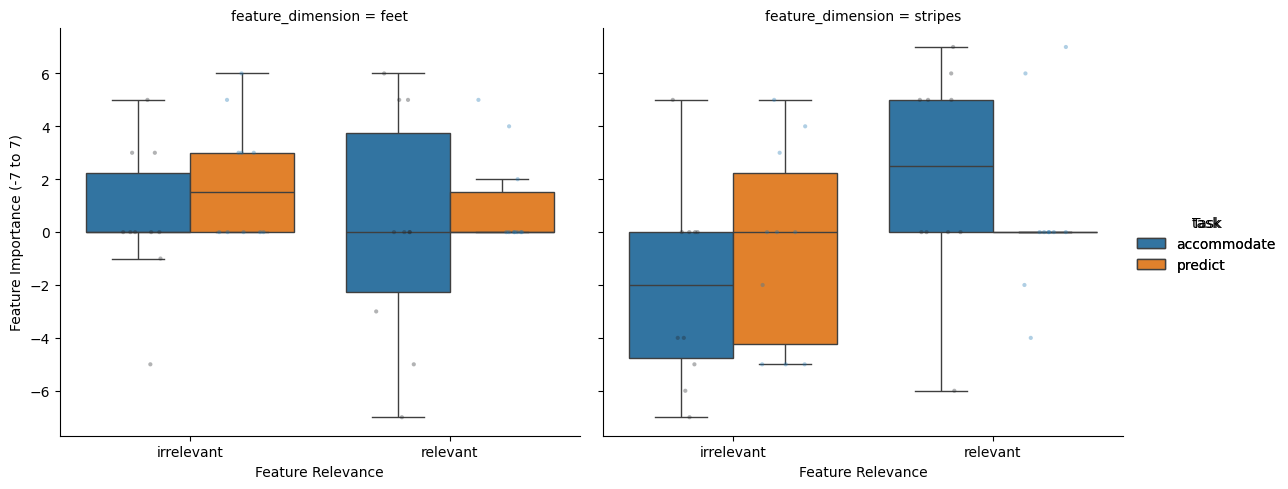

In [83]:
g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    col='feature_dimension',
    kind='box',
    height=5,
    aspect=1,
    showfliers=False
)

g.map_dataframe(
    sns.stripplot,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=0.18,
    alpha=0.35,
    size=3,
    legend=False
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'Figure4_FeatureImportance_BoxJitter_FacetedByDimension.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

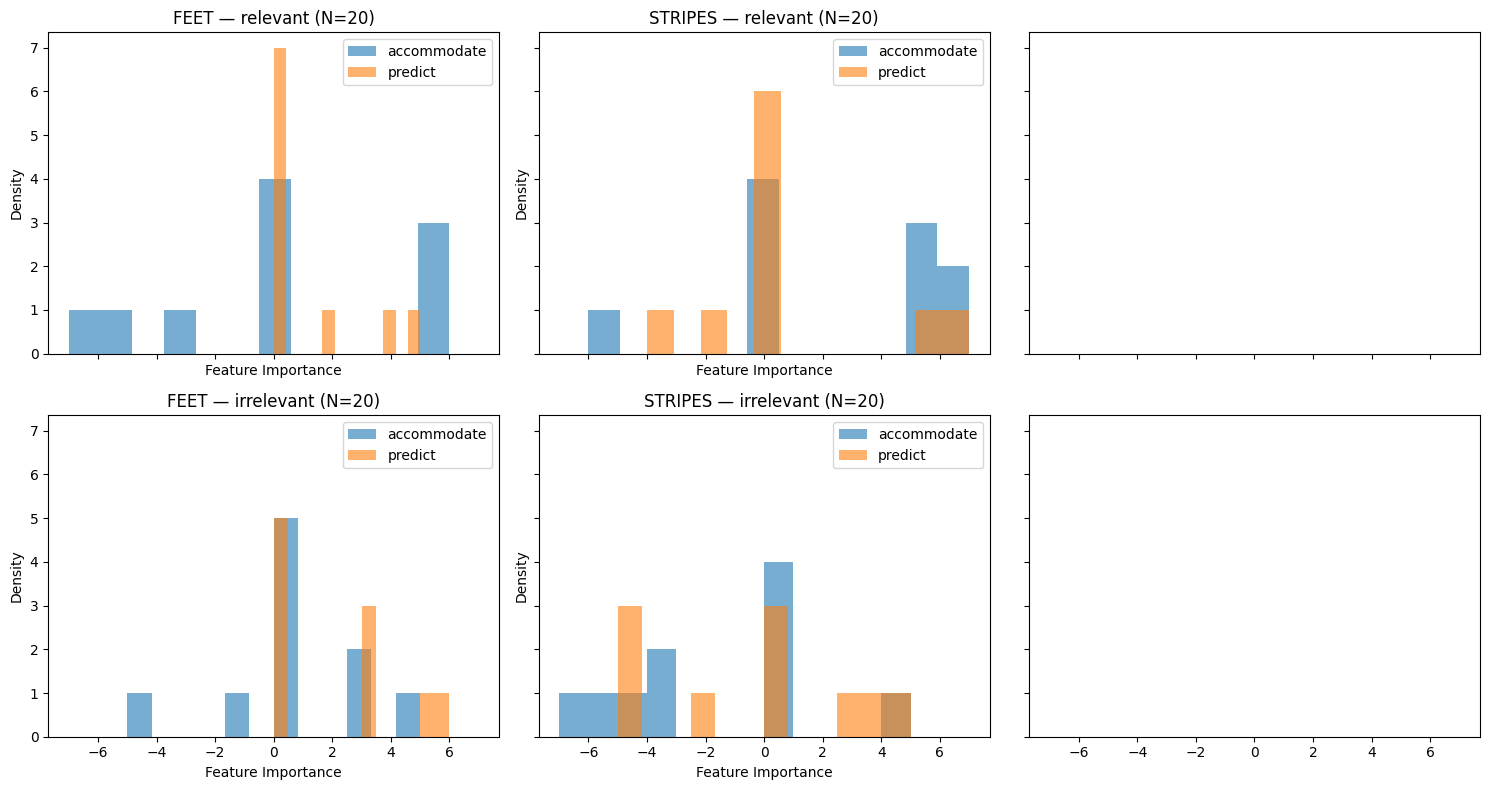

In [42]:
import matplotlib.pyplot as plt

features = ['feet', 'stripes']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        for task in tasks:
            subset = df_long[
                (df_long['feature_dimension'] == feat) &
                (df_long['feature_relevance'] == rel) &
                (df_long['task'] == task)
            ]

            ax.hist(
                subset['feature_importance'],
                bins=12,
                density=False,
                alpha=0.6,
                label=task
            )

        n_points = len(df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ])

        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Feature Importance")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceScoresbyFeaturesAndTask.png'))
plt.show()

In [43]:
print(df_long.head(220))

    participant         task relevant_dim irrelevant_dim stripes_high  \
0             1  accommodate      stripes           feet            W   
1             2  accommodate         feet        stripes            E   
2             3  accommodate         feet        stripes            W   
3             4  accommodate      stripes           feet            W   
4             5  accommodate         feet        stripes            E   
..          ...          ...          ...            ...          ...   
75           36      predict      stripes           feet            E   
76           37      predict         feet        stripes            W   
77           38      predict         feet        stripes            W   
78           39      predict         feet        stripes            W   
79           40      predict         feet        stripes            W   

   feet_high feet_discrete_slider.response feature_dimension  \
0          C                           Yes              fee

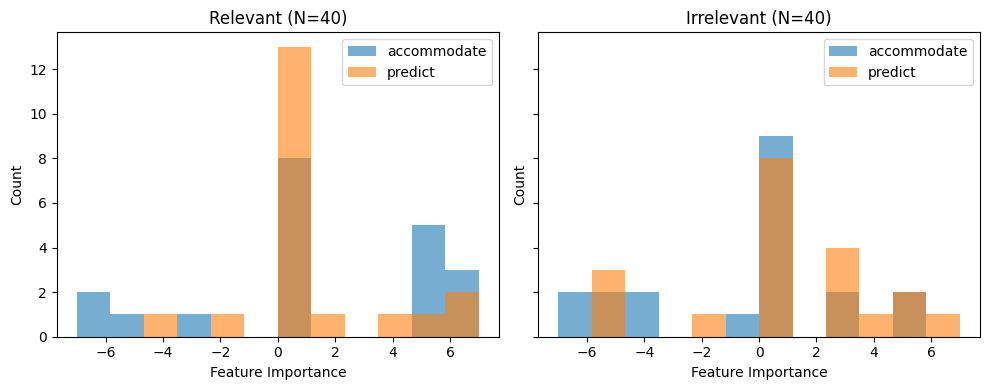

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import os

relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

# Common bins
bin_edges = np.linspace(
    df_long['feature_importance'].min(),
    df_long['feature_importance'].max(),
    13  # 12 bins = 13 edges
)

for i, rel in enumerate(relevance_states):
    ax = axes[i]

    for task in tasks:
        subset = df_long[
            (df_long['feature_relevance'] == rel) &
            (df_long['task'] == task)
        ]

        ax.hist(
            subset['feature_importance'],
            bins=bin_edges,
            alpha=0.6,
            label=task
        )

    n_points = len(df_long[df_long['feature_relevance'] == rel])

    ax.set_title(f"{rel.capitalize()} (N={n_points})")
    ax.set_xlabel("Feature Importance")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportance_byRelevance.png'))
plt.show()

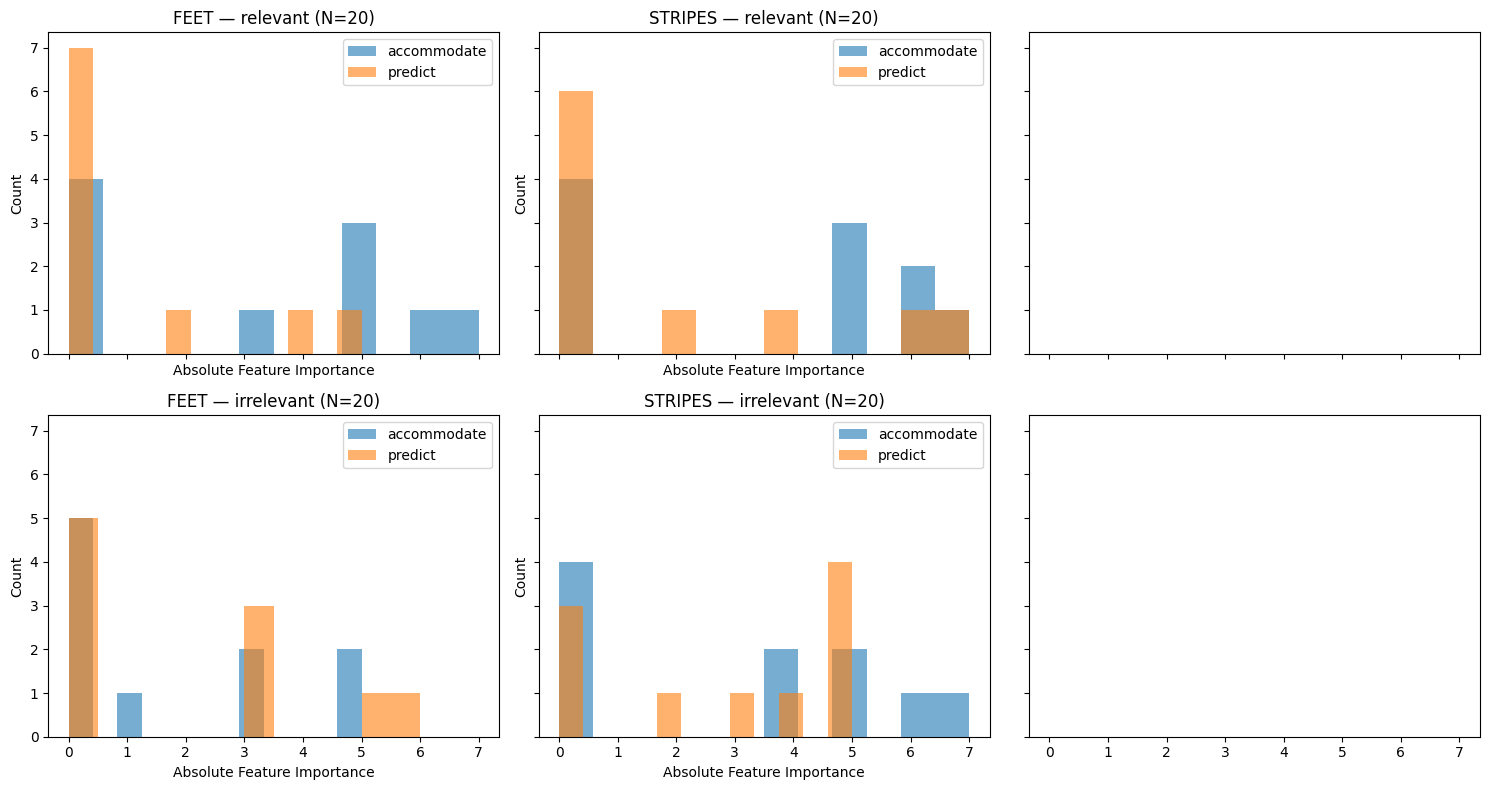

In [157]:
df_long['abs_feature_importance'] = df_long['feature_importance'].abs()
import matplotlib.pyplot as plt
import os

features = ['feet', 'stripes']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        for task in tasks:
            subset = df_long[
                (df_long['feature_dimension'] == feat) &
                (df_long['feature_relevance'] == rel) &
                (df_long['task'] == task)
            ]

            ax.hist(
                subset['abs_feature_importance'],
                bins=12,
                density=False,
                alpha=0.6,
                label=task
            )

        n_points = len(df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ])

        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Absolute Feature Importance")
        ax.set_ylabel("Count")
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'AbsoluteFeatureImportanceScoresbyFeaturesAndTask.png'))
plt.show()

In [192]:
g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='abs_feature_importance',
    hue='task',
    col='feature_dimension',
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    #density_norm='width',   
    #common_norm=False,     
    height=5,
    aspect=1
)

g.map_dataframe(
    sns.stripplot,
    x='feature_relevance',
    y='abs_feature_importance',
    hue='task',
    dodge=True,
    alpha=1,
    size=4.5,
    jitter=0.18,
    legend=False
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.add_legend(title='Task')

plt.show()

ValueError: Could not interpret value `abs_feature_importance` for `y`. An entry with this name does not appear in `data`.

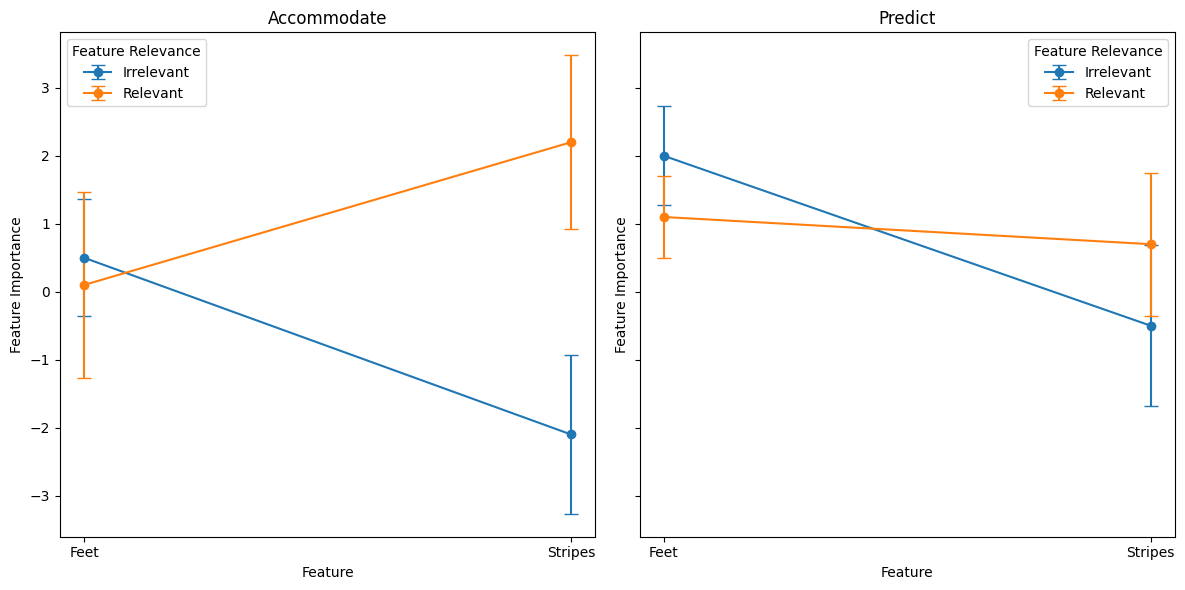

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import os

features = ['feet', 'stripes']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, task in enumerate(df_long["task"].unique()):
    ax = axes[i]
    
    task_df = df_long[df_long["task"] == task]

    for rel in ['irrelevant', 'relevant']:
        rel_df = task_df[task_df["feature_relevance"] == rel]
        
        means = []
        ses = []

        for feat in features:
            cell = rel_df[rel_df["feature_dimension"] == feat]["feature_importance"]
            
            means.append(cell.mean())
            ses.append(cell.std(ddof=1) / np.sqrt(len(cell)) if len(cell) > 1 else 0)

        label = rel.capitalize()
        ax.errorbar(
            range(len(features)),
            means,
            yerr=ses,
            marker='o',
            capsize=5,
            label=label
        )

    ax.set_title(task.capitalize())
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([f.capitalize() for f in features])
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature Importance")
    ax.legend(title="Feature Relevance")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure5FeatureImportanceByTaskAndRelevance.png'))
plt.show()

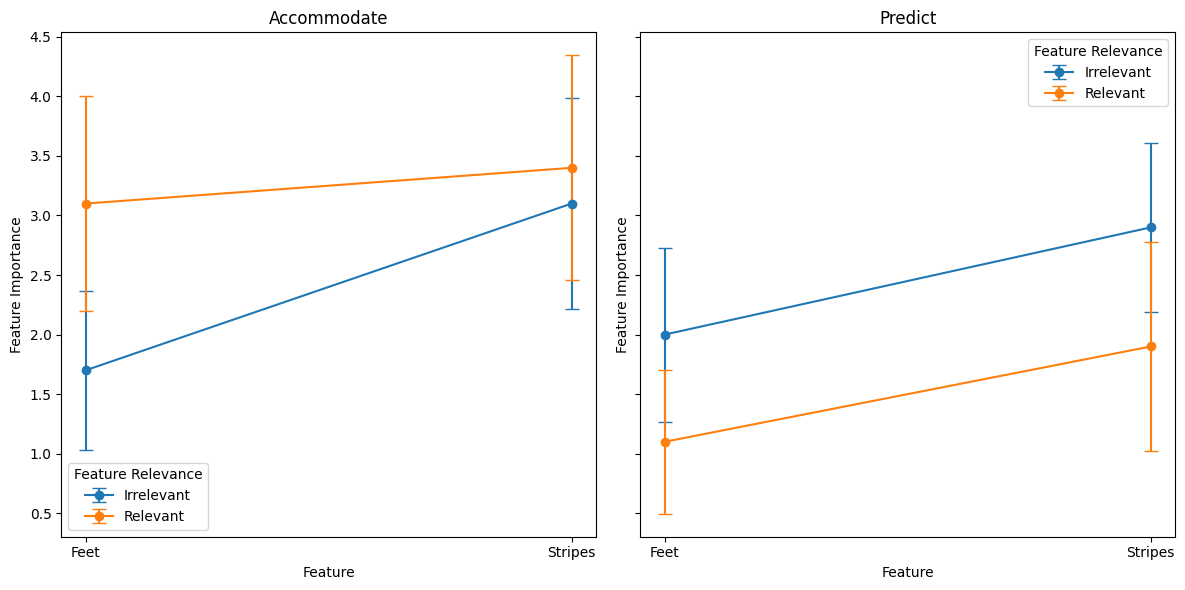

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import os

features = ['feet', 'stripes']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, task in enumerate(df_long["task"].unique()):
    ax = axes[i]
    
    task_df = df_long[df_long["task"] == task]

    for rel in ['irrelevant', 'relevant']:
        rel_df = task_df[task_df["feature_relevance"] == rel]
        
        means = []
        ses = []

        for feat in features:
            cell = rel_df[rel_df["feature_dimension"] == feat]["abs_feature_importance"]
            
            means.append(cell.mean())
            ses.append(cell.std(ddof=1) / np.sqrt(len(cell)) if len(cell) > 1 else 0)

        label = rel.capitalize()
        ax.errorbar(
            range(len(features)),
            means,
            yerr=ses,
            marker='o',
            capsize=5,
            label=label
        )

    ax.set_title(task.capitalize())
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([f.capitalize() for f in features])
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature Importance")
    ax.legend(title="Feature Relevance")

plt.tight_layout()
plt.show()

In [497]:
import statsmodels.formula.api as smf

#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['relevant', 'irrelevant'], ordered=False)

model = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStats.csv"))


                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         feature_importance
No. Observations:           868             Method:                     REML              
No. Groups:                 434             Scale:                      11.1189           
Min. group size:            2               Log-Likelihood:             -2277.2583        
Max. group size:            2               Converged:                  Yes               
Mean group size:            2.0                                                           
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        3.728    0.226 16.470 0.000  3.284  4.172
task[T.predict]           

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [498]:
print(df_long)
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_for_R-Study3.csv'), index=False)

     participant         task relevant_dim irrelevant_dim color_high  \
0              1  accommodate         feet          color          Y   
1              2  accommodate         feet          color          Y   
2              3  accommodate        color           feet          Y   
3              4  accommodate         feet          color          Y   
4              5  accommodate         feet          color          Y   
..           ...          ...          ...            ...        ...   
863          430      predict        color           feet          Y   
864          431      predict         feet          color          Y   
865          432      predict         feet          color          Y   
866          433      predict        color           feet          Y   
867          434      predict        color           feet          Y   

    feet_high feet_discrete_slider.response feature_dimension  \
0           F                            No              feet   
1    

In [499]:
means = (
    df_long
    .groupby(["task", "feature_relevance"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


          task feature_relevance      mean       std  count
0  accommodate          relevant  3.728111  3.436567    217
1  accommodate        irrelevant  1.110599  3.531174    217
2      predict          relevant  2.935484  3.432616    217
3      predict        irrelevant  1.087558  2.900620    217


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/1213789995.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance"])["feature_importance"]


In [51]:
means = (
    df_long
    .groupby(["task", "feature_relevance", "feature_dimension"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


          task feature_relevance feature_dimension  mean       std  count
0  accommodate        irrelevant              feet   0.5  2.718251     10
1  accommodate        irrelevant           stripes  -2.1  3.695342     10
2  accommodate          relevant              feet   0.1  4.332051     10
3  accommodate          relevant           stripes   2.2  4.049691     10
4      predict        irrelevant              feet   2.0  2.309401     10
5      predict        irrelevant           stripes  -0.5  3.749074     10
6      predict          relevant              feet   1.1  1.911951     10
7      predict          relevant           stripes   0.7  3.335000     10


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/3454135323.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "feature_relevance", "feature_dimension"])["feature_importance"]


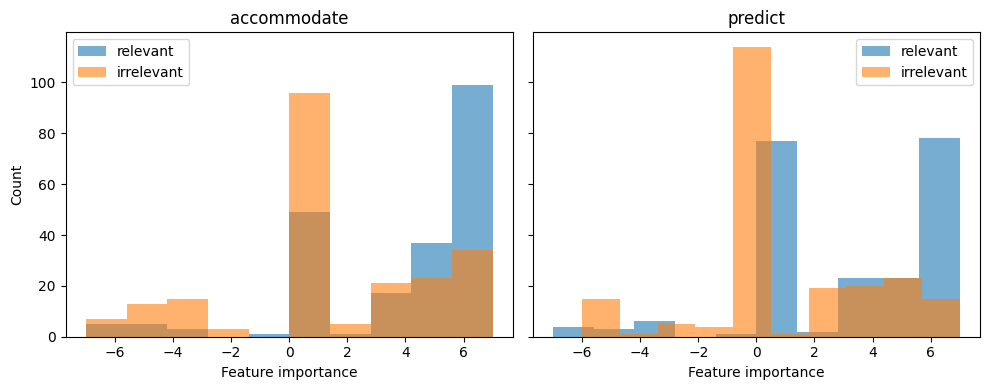

In [501]:
tasks = df_long['task'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tasks),
    figsize=(5 * len(tasks), 4),
    sharey=True
)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    for label in ['relevant', 'irrelevant']:
        values = df_long.loc[
            (df_long['task'] == task) &
            (df_long['feature_relevance'] == label),
            'feature_importance'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=label)

    ax.set_title(task)
    ax.set_xlabel("Feature importance")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3_FeatureImportanceByTaskAndRelevance.png'), dpi=300)
plt.show()


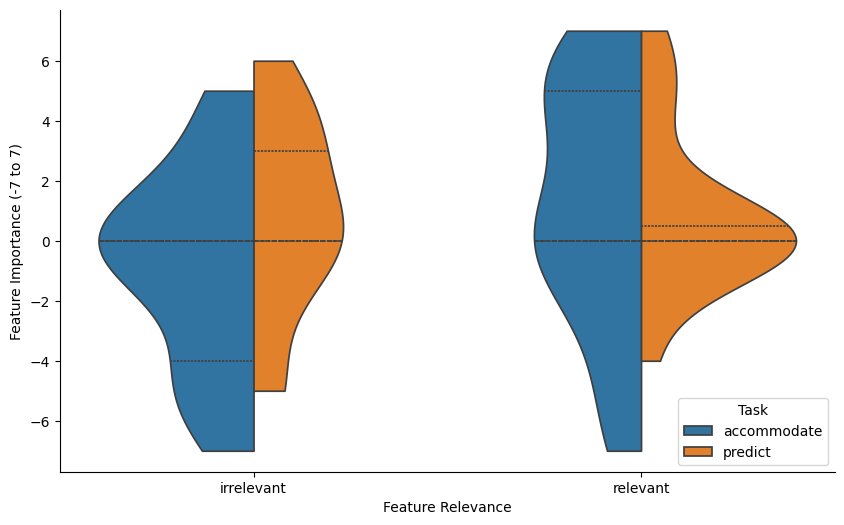

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc='lower right')
plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()


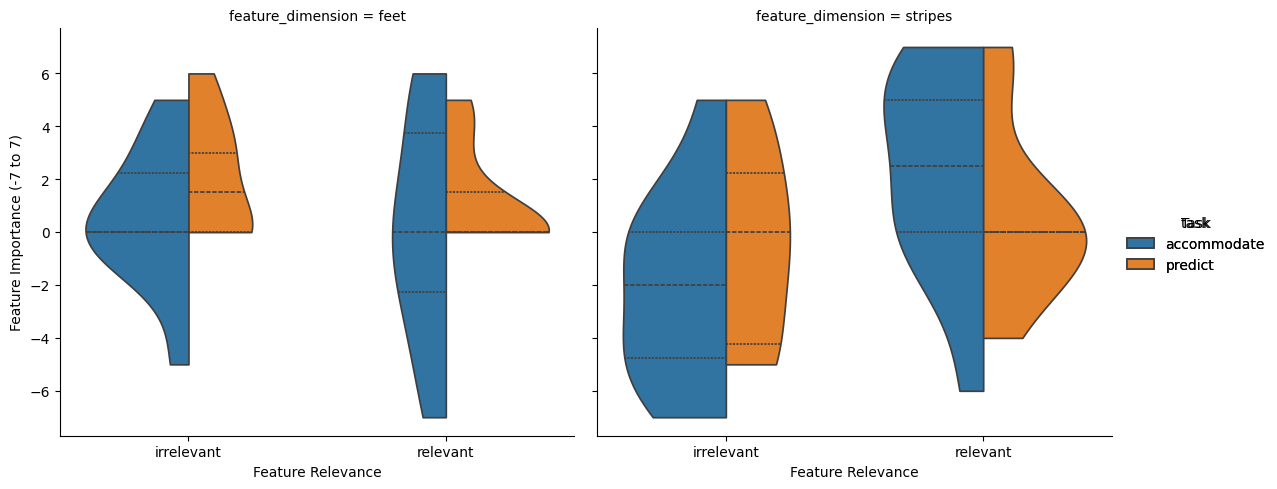

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_long['feature_relevance'] = pd.Categorical(
    df_long['feature_relevance'],
    categories=['irrelevant', 'relevant'],
    ordered=False
)

g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    col='feature_dimension',     
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    height=5,
    aspect=1
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.add_legend(title='Task')

sns.despine()

plt.savefig(
    os.path.join(outputdir, 'Figure4_FeatureImportance_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300
)

plt.show()

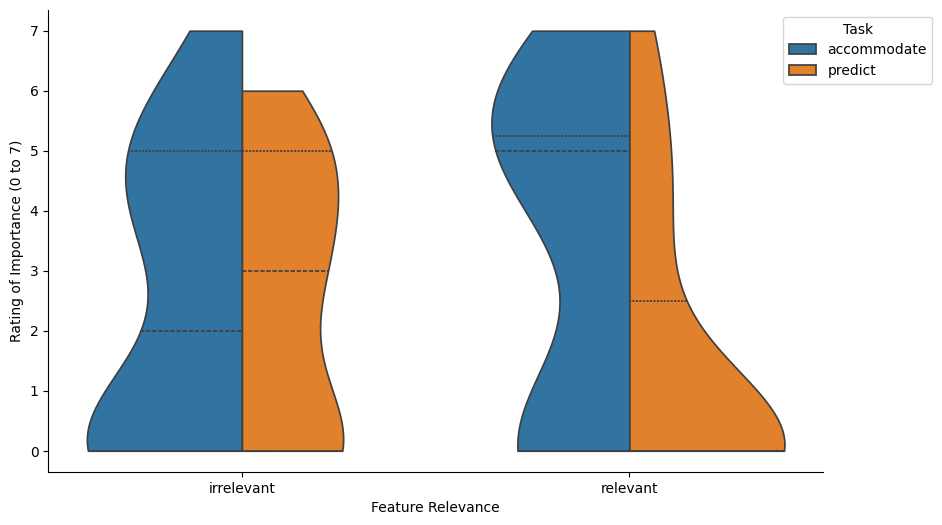

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='abs_feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Rating of Importance (0 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc ='upper right', bbox_to_anchor=(1.15, 1))
#plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()


In [503]:
df_long['task'] = df_long['task'].astype('category')  # predict/accomodate
df_long['feature_dimension'] = df_long['feature_dimension'].astype('category')
df_long['feature_relevance'] = df_long['feature_relevance'].astype('category')


In [504]:
import statsmodels.formula.api as smf

# Predicting feature importance from task and feature relevance, with random intercepts for participants
md = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"],  # random intercept per participant
    re_formula="~feature_relevance" # random slopes
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_featureimportance.csv"))

                         Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         feature_importance
No. Observations:         868             Method:                     REML              
No. Groups:               434             Scale:                      7.9917            
Min. group size:          2               Log-Likelihood:             -2276.4388        
Max. group size:          2               Converged:                  Yes               
Mean group size:          2.0                                                           
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      1.111    0.219  5.063 0.000  0.681  1.541
task[T.predict]                               -

In [50]:
#Analyse the absolute value of feature importance ratings (ignoring direction)
df_longAbs = df_long.copy()
df_longAbs["abs_feature_importance"] = df_longAbs["feature_importance"].abs()
avg_importance_task = (
    df_longAbs
        .groupby(['task', 'feature_relevance'])['abs_feature_importance']
        .mean()
        .reset_index()
)
print(avg_importance_task)
avg_importance_relevance = (
    df_longAbs
        .groupby(['feature_relevance'])['abs_feature_importance']
        .mean()
        .reset_index()
)

print(avg_importance_relevance)

avg_importance_feature = (
    df_longAbs
        .groupby(['feature_dimension'])['abs_feature_importance']
        .mean()
        .reset_index()
)
print(avg_importance_feature)

          task feature_relevance  abs_feature_importance
0  accommodate        irrelevant                    2.40
1  accommodate          relevant                    3.25
2      predict        irrelevant                    2.45
3      predict          relevant                    1.50
  feature_relevance  abs_feature_importance
0        irrelevant                   2.425
1          relevant                   2.375
  feature_dimension  abs_feature_importance
0              feet                   1.975
1           stripes                   2.825


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/1409563864.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'feature_relevance'])['abs_feature_importance']
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/1409563864.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['feature_relevance'])['abs_feature_importance']


In [506]:
df_irrel = df_longAbs[df_longAbs["feature_relevance"] == "irrelevant"].copy()

accom_vals = df_irrel[df_irrel["task"]=="accommodate"]["abs_feature_importance"]
predict_vals = df_irrel[df_irrel["task"]=="predict"]["abs_feature_importance"]
mean_accom = np.mean(accom_vals)
mean_predict = np.mean(predict_vals)

print(f"Mean (accommodate) = {mean_accom:.3f}")
print(f"Mean (predict) = {mean_predict:.3f}")
t, p = ttest_ind(predict_vals, accom_vals, equal_var=False)  # Welch's t-test
print(f"t = {t:.3f}, p = {p:.4f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_feature_importance": [mean_accom, mean_predict],
    "t_stat": [t, t], 
    "p_value": [p, p]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_abs_featureimportance.csv"))

Mean (accommodate) = 2.650
Mean (predict) = 2.046
t = -2.562, p = 0.0108


**Analysis 3: Predicting Fertility Ratings**

In [203]:
#Group by average food amount per item in training
df = df_combined[['task', 'training_image_order', 'fertility_score', 'conditionOrder']]
df_long2 = (
    df
    .explode(['training_image_order', 'fertility_score'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food = (
    df_long2
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    ['fertility_score']
    .mean()
)
avg_food_train = avg_food.copy()
print(avg_food_train.head(20))


           task  conditionOrder item fertility_score
0   accommodate               1  E_C             8.0
1   accommodate               1  E_F             3.0
2   accommodate               1  W_C             8.0
3   accommodate               1  W_F             4.0
4   accommodate               2  E_C             3.5
5   accommodate               2  E_F             3.0
6   accommodate               2  W_C             8.0
7   accommodate               2  W_F             7.5
8   accommodate               3  E_C            3.75
9   accommodate               3  E_F             7.5
10  accommodate               3  W_C             5.0
11  accommodate               3  W_F             4.5
12  accommodate               4  E_C            8.25
13  accommodate               4  E_F             7.0
14  accommodate               4  W_C             3.0
15  accommodate               4  W_F            1.75
16  accommodate               5  E_C            7.75
17  accommodate               5  E_F          

In [204]:
#Get food consumption ratings by item

df = df_combined[['task', 'conditionOrder', 'testing_image_order', 'testing_responses',
                  'relevant_dim', 'irrelevant_dim', 'stripes_high', 'feet_high']]
df_long2 = (
    df
    .explode(['testing_image_order', 'testing_responses'])
    .rename(columns={'testing_image_order': 'item'})
)
avg_food_test = df_long2.copy()
print(avg_food_test)


           task  conditionOrder item testing_responses relevant_dim  \
0   accommodate              18  E_C               6.0      stripes   
0   accommodate              18  W_F               4.0      stripes   
0   accommodate              18  W_C              10.0      stripes   
0   accommodate              18  E_F               6.0      stripes   
1   accommodate               5  W_F               7.0         feet   
..          ...             ...  ...               ...          ...   
38      predict               9  E_C              10.0         feet   
39      predict              17  W_F               8.0         feet   
39      predict              17  E_F               3.0         feet   
39      predict              17  W_C               3.0         feet   
39      predict              17  E_C               8.0         feet   

   irrelevant_dim stripes_high feet_high  
0            feet            W         C  
0            feet            W         C  
0            feet 

In [205]:
#Now merge the two (actual food amounts in training vs ratings in testing) and compute error
df_merged = avg_food_test.merge(
    avg_food_train,
    on=['task', 'conditionOrder', 'item'],
    how='left'
)

#Add Error and absolute error
df_merged['error'] = (
    df_merged['testing_responses'] - df_merged['fertility_score']
)
df_merged['abs_error'] = df_merged['error'].abs()
df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print(df_merged)

            task  conditionOrder item testing_responses relevant_dim  \
0    accommodate              18  E_C               6.0      stripes   
1    accommodate              18  W_F               4.0      stripes   
2    accommodate              18  W_C              10.0      stripes   
3    accommodate              18  E_F               6.0      stripes   
4    accommodate               5  W_F               7.0         feet   
..           ...             ...  ...               ...          ...   
155      predict               9  E_C              10.0         feet   
156      predict              17  W_F               8.0         feet   
157      predict              17  E_F               3.0         feet   
158      predict              17  W_C               3.0         feet   
159      predict              17  E_C               8.0         feet   

    irrelevant_dim stripes_high feet_high fertility_score error abs_error  \
0             feet            W         C            3.25 

In [206]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['stripes', 'feet']] = df_merged['item'].str.split('_', expand=True)
print("Mean error by stripes:")
print(df_merged.groupby('stripes')['error'].mean())

print("Mean error by feet:")
print(df_merged.groupby('feet')['error'].mean())
#t-test: stripes 1 vs stripes 2 absolute error 
stripes1 = df_merged.loc[df_merged['feet'] == 'C', 'error']
stripes2 = df_merged.loc[df_merged['feet'] == 'F', 'error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(stripes1), pd.to_numeric(stripes2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean error by stripes:
stripes
E    0.59375
W     0.2125
Name: error, dtype: object
Mean error by feet:
feet
C    0.45625
F       0.35
Name: error, dtype: object
T = 0.262, p = 0.794


C
F


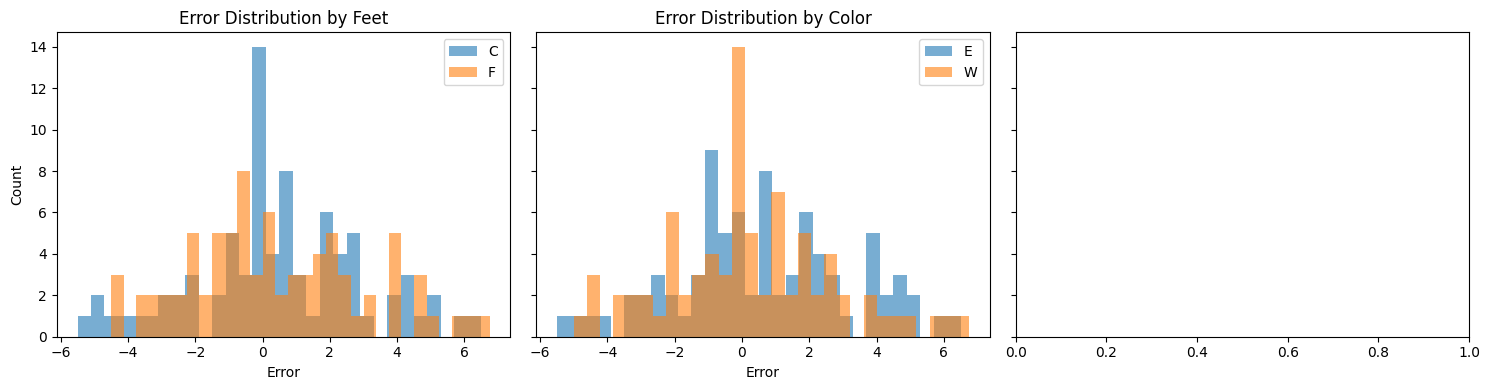

In [58]:
import matplotlib.pyplot as plt

# Make sure error is numeric
df_merged['error'] = pd.to_numeric(df_merged['error'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Tail
for t in df_merged['feet'].unique():
    print(t)
    axes[0].hist(
        df_merged.loc[df_merged['feet'] == t, 'error'],
        bins=30,
        alpha=0.6,
        label=t
    )
axes[0].set_title('Error Distribution by Feet')
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Color ---
for c in df_merged['color'].unique():
    axes[1].hist(
        df_merged.loc[df_merged['color'] == c, 'error'],
        bins=30,
        alpha=0.6,
        label=c
    )
axes[1].set_title('Error Distribution by Color')
axes[1].set_xlabel('Error')
axes[1].legend()

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure7_ErrorDistributionByFeature.png'), dpi=300)
plt.show()


In [59]:
print(df_merged)

            task  conditionOrder item testing_responses relevant_dim  \
0    accommodate              18  E_C               6.0      stripes   
1    accommodate              18  W_F               4.0      stripes   
2    accommodate              18  W_C              10.0      stripes   
3    accommodate              18  E_F               6.0      stripes   
4    accommodate               5  W_F               7.0         feet   
..           ...             ...  ...               ...          ...   
155      predict               9  E_C              10.0         feet   
156      predict              17  W_F               8.0         feet   
157      predict              17  E_F               3.0         feet   
158      predict              17  W_C               3.0         feet   
159      predict              17  E_C               8.0         feet   

    irrelevant_dim stripes_high feet_high fertility_score  error abs_error  \
0             feet            W         C            3.25

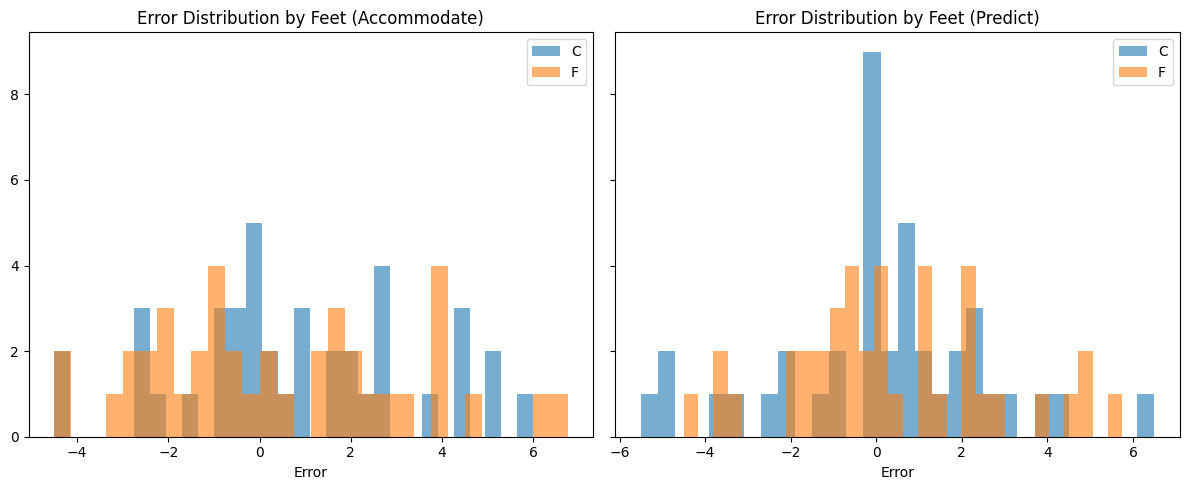

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, task in enumerate(['accommodate', 'predict']):
    for w in df_merged['feet'].unique():
        axes[i].hist(
            df_merged.loc[(df_merged['feet'] == w) & (df_merged['task'] == task), 'error'],
            bins=30,
            alpha=0.6,
            label=w
        )
    axes[i].set_title(f'Error Distribution by Feet ({task.capitalize()})')
    axes[i].set_xlabel('Error')
    axes[i].legend()

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure7b_ErrorDistributionByFeetAndTask.png'), dpi=300)
plt.show()

In [ ]:
#df filtered same as above
#Group by average food amount per item in training
df = df_filtered[['task', 'training_image_order', 'fertility_score', 'conditionOrder']]
df_long2filtered = (
    df
    .explode(['training_image_order', 'fertility_score'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food = (
    df_long2filtered
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    ['fertility_score']
    .mean()
)
avg_food_train = avg_food.copy()
print(avg_food_train.head(20))

#Get food consumption ratings by item

df = df_filtered[['task', 'conditionOrder', 'testing_image_order', 'testing_responses',
                  'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high']]
df_long2 = (
    df
    .explode(['testing_image_order', 'testing_responses'])
    .rename(columns={'testing_image_order': 'item'})
)
avg_food_test = df_long2.copy()
print(avg_food_test)


#Now merge the two (actual food amounts in training vs ratings in testing) and compute error
df_merged = avg_food_test.merge(
    avg_food_train,
    on=['task', 'conditionOrder', 'item'],
    how='left'
)

#Add Error and absolute error
df_merged['error'] = (
    df_merged['testing_responses'] - df_merged['fertility_score']
)
df_merged['abs_error'] = df_merged['error'].abs()
df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print(df_merged)


In [61]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print("Mean abs_error by color:")
print(df_merged.groupby('color')['abs_error'].mean())

print("Mean abs_error by feet:")
print(df_merged.groupby('feet')['abs_error'].mean())
#t-test: color 1 vs color 2 absolute error 
color1 = df_merged.loc[df_merged['feet'] == 'C', 'abs_error']
color2 = df_merged.loc[df_merged['feet'] == 'F', 'abs_error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(color1), pd.to_numeric(color2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean abs_error by color:
color
E    2.10625
W    1.90625
Name: abs_error, dtype: object
Mean abs_error by feet:
feet
C    1.93125
F    2.08125
Name: abs_error, dtype: object
T = -0.580, p = 0.563


In [62]:
#t-test: predict vs accomodate absolute error
df_merged['error'] = pd.to_numeric(df_merged['abs_error'])
print(df_merged.groupby('task')['error'].mean())
errors_task1 = df_merged.loc[df_merged['task'] == 'accommodate', 'error']
errors_task2 = df_merged.loc[df_merged['task'] == 'predict', 'error']
from scipy import stats
t_stat, p_val = stats.ttest_ind(errors_task1, errors_task2, equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_error": [errors_task1.mean(), errors_task2.mean()],
    "t_stat": [t_stat, t_stat], 
    "p_value": [p_val, p_val]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_error.csv"))

task
accommodate    2.184375
predict        1.828125
Name: error, dtype: float64
T = 1.384, p = 0.168


In [37]:
#t-test: predict vs accomodate absolute error
df_merged['abs_error'] = pd.to_numeric(df_merged['abs_error'])
print(df_merged.groupby('task')['abs_error'].mean())
errors_task1 = df_merged.loc[df_merged['task'] == 'accommodate', 'abs_error']
errors_task2 = df_merged.loc[df_merged['task'] == 'predict', 'abs_error']
from scipy import stats
t_stat, p_val = stats.ttest_ind(errors_task1, errors_task2, equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_error": [errors_task1.mean(), errors_task2.mean()],
    "t_stat": [t_stat, t_stat], 
    "p_value": [p_val, p_val]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_error.csv"))

task
accommodate    1.191761
predict        1.323106
Name: abs_error, dtype: float64
T = -2.320, p = 0.020


Part 2: Correlations

In [207]:
# df_params
df_params['id'] = list(zip(df_params['task'], df_params['conditionOrder']))

# df_corr already has this
df_corr['id'] = df_corr['participant']

# Now merge cleanly
df_merged_test = df_params.merge(df_corr, on='id', how='inner')

In [208]:
# Columns indicating whether the item's feature is the "high" dimension (1 or 0 coding)
df_merged['stripes_match_high']  = (df_merged['stripes']  == df_merged['stripes_high']).astype(int)
df_merged['feet_match_high'] = (df_merged['feet'] == df_merged['feet_high']).astype(int)
#print(df_merged.head(20))
# Group by participant
participant_corrs = []

for pid, g in df_merged.groupby(['task', 'conditionOrder']):
    for feat in ['stripes','feet']:
        # Column indicating match to high value
        match_col = f"{feat}_match_high"
        
        # Compute correlation
        corr = g['testing_responses'].corr(g[match_col])
        
        # Determine if this feature is relevant for this participant
        relevant = g['relevant_dim'].iloc[0] == feat
        high_col  = f"{feat}_high"
        
        # Store
        participant_corrs.append({
            'participant': pid,
            'task': g['task'].iloc[0],
            'feature_dimension': feat,
            'high_value': g[high_col].iloc[0],
            'feature_relevance': 'relevant' if relevant else 'irrelevant',
            'correlation': corr,
            'irrelevant_dim': g['irrelevant_dim'].iloc[0],
            'abs_correlation': abs(corr) if pd.notna(corr) else None
        })

df_corr = pd.DataFrame(participant_corrs)
print(df_corr.tail(40))



      participant     task feature_dimension high_value feature_relevance  \
40   (predict, 1)  predict           stripes          W        irrelevant   
41   (predict, 1)  predict              feet          C          relevant   
42   (predict, 2)  predict           stripes          W          relevant   
43   (predict, 2)  predict              feet          C        irrelevant   
44   (predict, 3)  predict           stripes          E        irrelevant   
45   (predict, 3)  predict              feet          F          relevant   
46   (predict, 4)  predict           stripes          E          relevant   
47   (predict, 4)  predict              feet          C        irrelevant   
48   (predict, 5)  predict           stripes          E        irrelevant   
49   (predict, 5)  predict              feet          C          relevant   
50   (predict, 6)  predict           stripes          W          relevant   
51   (predict, 6)  predict              feet          C        irrelevant   

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [452]:
df_corr.to_csv(os.path.join(outputdirCleaned, 'df_corr_for_R.csv'), index=False)

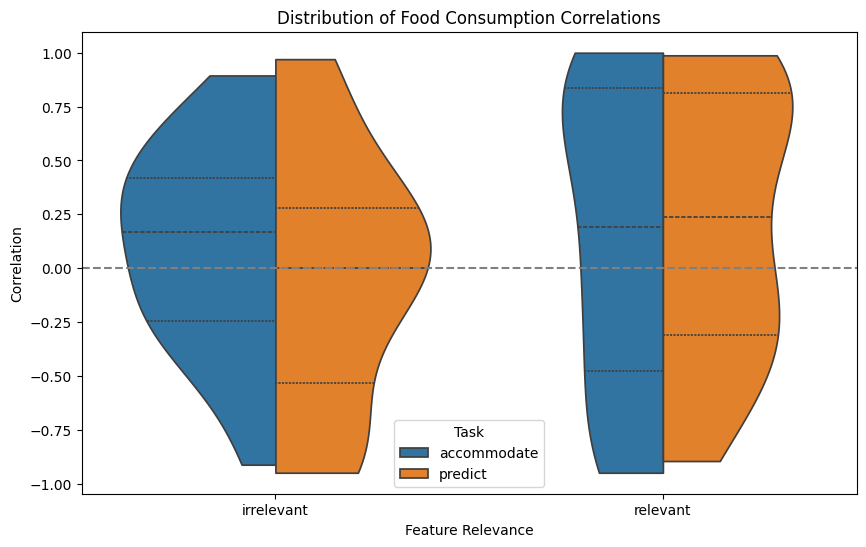

In [212]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_corr,
    x='feature_relevance',      # relevant / irrelevant
    y='correlation',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0,

)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Food Consumption Correlations')
plt.ylabel('Correlation')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'Figure10_FeatureCorrelationeByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2251855743.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_71612/2251855743.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


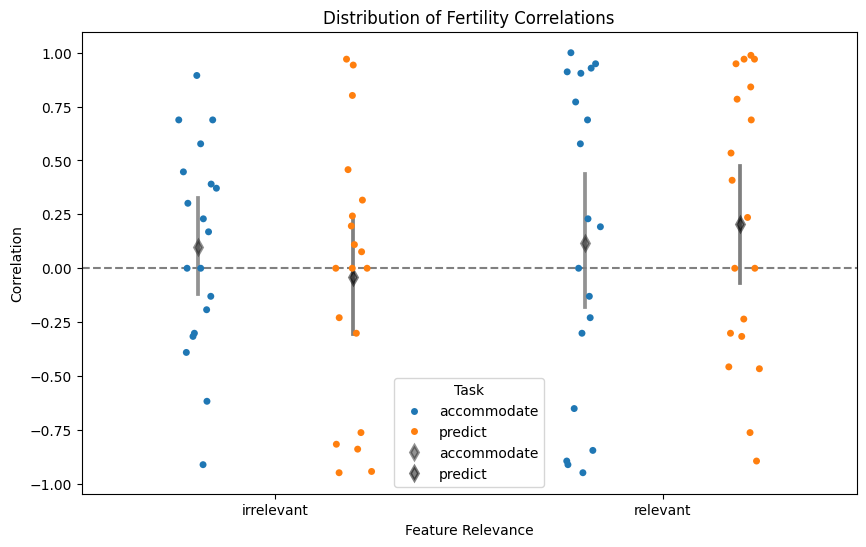

In [231]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.stripplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Correlations')
plt.ylabel('Correlation')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'Figure10_FeatureCorrelationeByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove th

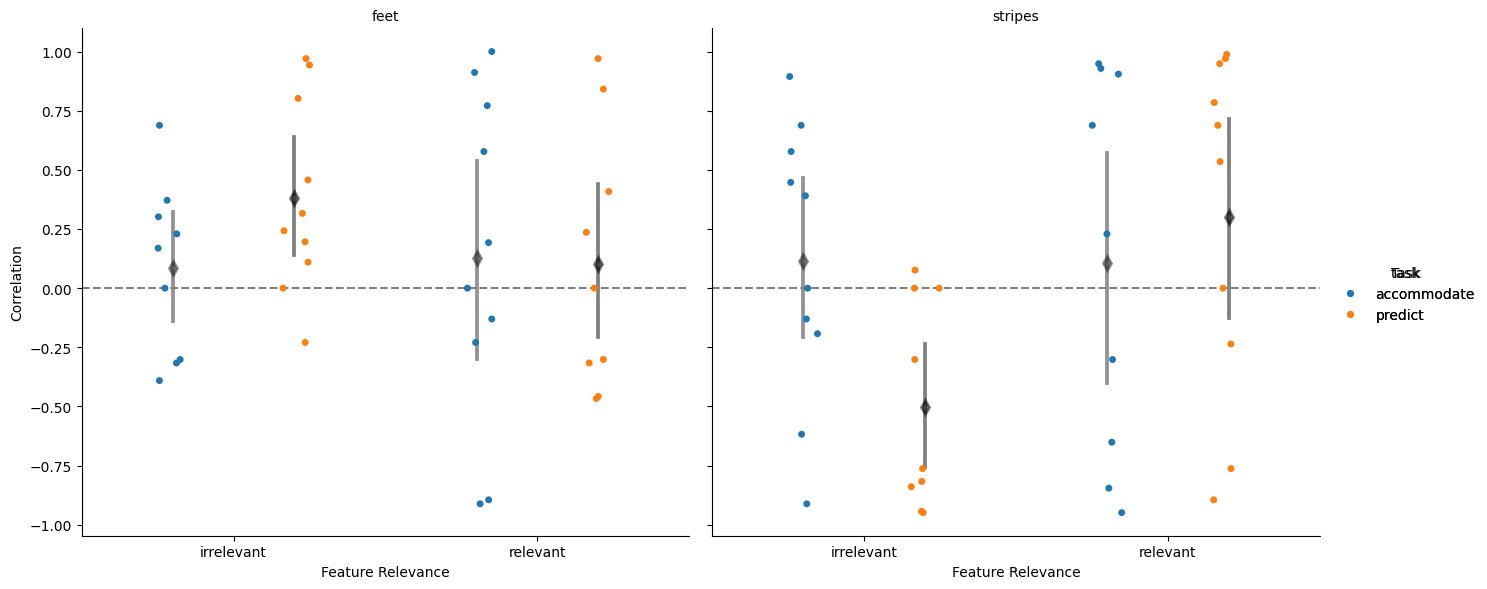

In [230]:
g = sns.catplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    col='feature_dimension',
    col_order=['feet', 'stripes'],   # <-- enforce left/right order
    kind='strip',
    dodge=True,
    jitter=.1,
    height=6,
    aspect=1
)

g.map_dataframe(
    sns.pointplot,
    x='feature_relevance',
    y='correlation',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.5,
    legend=False
)

for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--')

g.set_axis_labels('Feature Relevance', 'Correlation')
g.set_titles('{col_name}')
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'Figure10_FeatureCorrelation_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

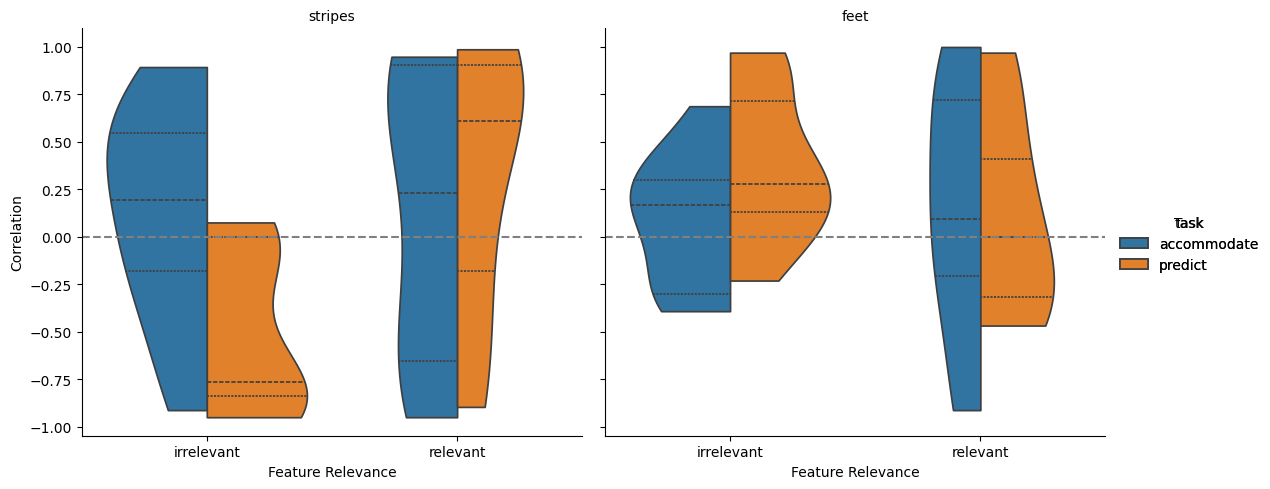

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    col='feature_dimension',   # <-- facet here
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    height=5,
    aspect=1
)

# Add horizontal line at 0 to each facet
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--')

g.set_axis_labels('Feature Relevance', 'Correlation')
g.set_titles('{col_name}')  # shows feature_dimension in each panel
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'Figure10_FeatureCorrelation_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300
)

plt.show()

In [369]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "correlation ~ task * feature_relevance",
    df_corr,
    groups=df_corr["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(
    os.path.join(outputdir, "Figure11_mixedlm_correlationStats.csv")
)

                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           correlation
No. Observations:            868               Method:                       REML       
No. Groups:                  434               Scale:                        0.2610     
Min. group size:             2                 Log-Likelihood:               -656.4278  
Max. group size:             2                 Converged:                    Yes        
Mean group size:             2.0                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      0.177    0.035  5.105 0.000  0.109  0.245
task[T.predict]                               -

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [67]:
avg_corr_task_rel = df_corr.groupby(
    ['task'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)
avg_corr_feature = df_corr.groupby(
    ['feature_dimension'],
    as_index=False
)['correlation'].mean()

print(avg_corr_feature)
avg_corr_relevance = df_corr.groupby(
    ['feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_relevance)

          task  correlation
0  accommodate     0.108902
1      predict     0.084416
  feature_dimension  correlation
0              feet     0.177890
1           stripes     0.015427
  feature_relevance  correlation
0        irrelevant     0.030805
1          relevant     0.162512


In [68]:
print(df_corr.tail(20))

      participant     task feature_dimension high_value feature_relevance  \
60  (predict, 11)  predict           stripes          W        irrelevant   
61  (predict, 11)  predict              feet          F          relevant   
62  (predict, 12)  predict           stripes          E          relevant   
63  (predict, 12)  predict              feet          F        irrelevant   
64  (predict, 13)  predict           stripes          W        irrelevant   
65  (predict, 13)  predict              feet          C          relevant   
66  (predict, 14)  predict           stripes          W          relevant   
67  (predict, 14)  predict              feet          C        irrelevant   
68  (predict, 15)  predict           stripes          W        irrelevant   
69  (predict, 15)  predict              feet          F          relevant   
70  (predict, 16)  predict           stripes          E          relevant   
71  (predict, 16)  predict              feet          F        irrelevant   

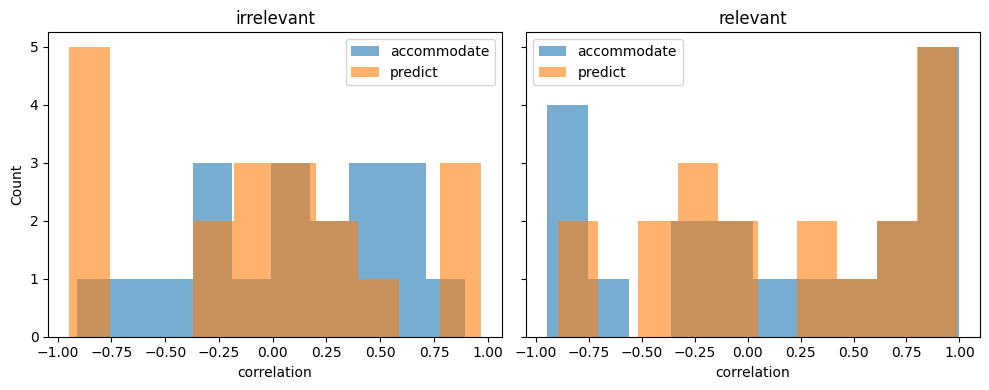

In [69]:
relevance_states = df_corr['feature_relevance'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(relevance_states),
    figsize=(5 * len(relevance_states), 4),
    sharey=True
)

if len(relevance_states) == 1:
    axes = [axes]

for ax, rel in zip(axes, relevance_states):
    for task in df_corr['task'].unique():
        values = df_corr.loc[
            (df_corr['feature_relevance'] == rel) &
            (df_corr['task'] == task),
            'correlation'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=task)

    ax.set_title(rel)
    ax.set_xlabel("correlation")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure9_FeatureCorrelationByRelevanceAndTask.png'), dpi=300)
plt.show()

In [70]:
avg_corr_task_rel = df_corr.groupby(
    ['task', 'feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)


          task feature_relevance  correlation
0  accommodate        irrelevant     0.099891
1  accommodate          relevant     0.117913
2      predict        irrelevant    -0.038280
3      predict          relevant     0.207111


In [71]:
avg_corr_task_rel = df_corr.groupby(
    ['task', 'feature_relevance'],
    as_index=False
)['abs_correlation'].mean()

print(avg_corr_task_rel)


          task feature_relevance  abs_correlation
0  accommodate        irrelevant         0.400888
1  accommodate          relevant         0.634929
2      predict        irrelevant         0.471264
3      predict          relevant         0.568596


In [381]:
import statsmodels.formula.api as smf

model = smf.ols(
    "abs_correlation ~ task * feature_relevance",
    df_corr
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        abs_correlation   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     86.09
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           9.63e-49
Time:                        13:20:09   Log-Likelihood:                -213.85
No. Observations:                 868   AIC:                             435.7
Df Residuals:                     864   BIC:                             454.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [384]:
nan_corrs = df_corr[pd.isna(df_corr['correlation'])]
#print(nan_corrs)
df_corr_clean = df_corr[pd.notna(df_corr['correlation'])].copy()



In [385]:
import statsmodels.formula.api as smf

md = smf.mixedlm(
    "correlation ~ task * feature_relevance",
    df_corr_clean,
    groups=df_corr_clean["participant"],  # random intercept per participant
    re_formula="~feature_relevance"  # random slopes if it converges
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_correlation.csv"))


                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           correlation
No. Observations:            868               Method:                       REML       
No. Groups:                  434               Scale:                        0.1909     
Min. group size:             2                 Log-Likelihood:               -646.7096  
Max. group size:             2                 Converged:                    Yes        
Mean group size:             2.0                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      0.177    0.031  5.658 0.000  0.116  0.238
task[T.predict]                               -

Supplementary: Irrelevant Feature Association with food amount and food consumption ratings

Supplementary Models Looking at Feature Dimension

In [412]:
import pandas as pd
from scipy.stats import chi2_contingency

# Loop through rows and determine model parameter score for each participant
participant_rows = []

for _, row in df_filtered.iterrows():
    feet_yes  = 1 if row['feet_discrete_slider.response'] == 'Yes' else 0
    color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0

    model_param_score = feet_yes + color_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'irrelevant_dim': row['irrelevant_dim'],
        'feet_high': row['feet_high'],
        'overfit': model_param_score == 2  # overfit if both dimensions selected
    })

df_params = pd.DataFrame(participant_rows)

# Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit      False  True 
task                     
accommodate    111     93
predict        140     64
Chi-square = 8.117
df = 1
p-value = 0.0044


model_param_score         task irrelevant_dim     0     1     2
0                  accommodate          color  11.0  41.0  43.0
1                  accommodate           feet  10.0  49.0  50.0
2                      predict          color  21.0  49.0  27.0
3                      predict           feet  14.0  56.0  37.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/2493775690.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim', 'model_param_score'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/2493775690.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = score_counts.pivot_table(


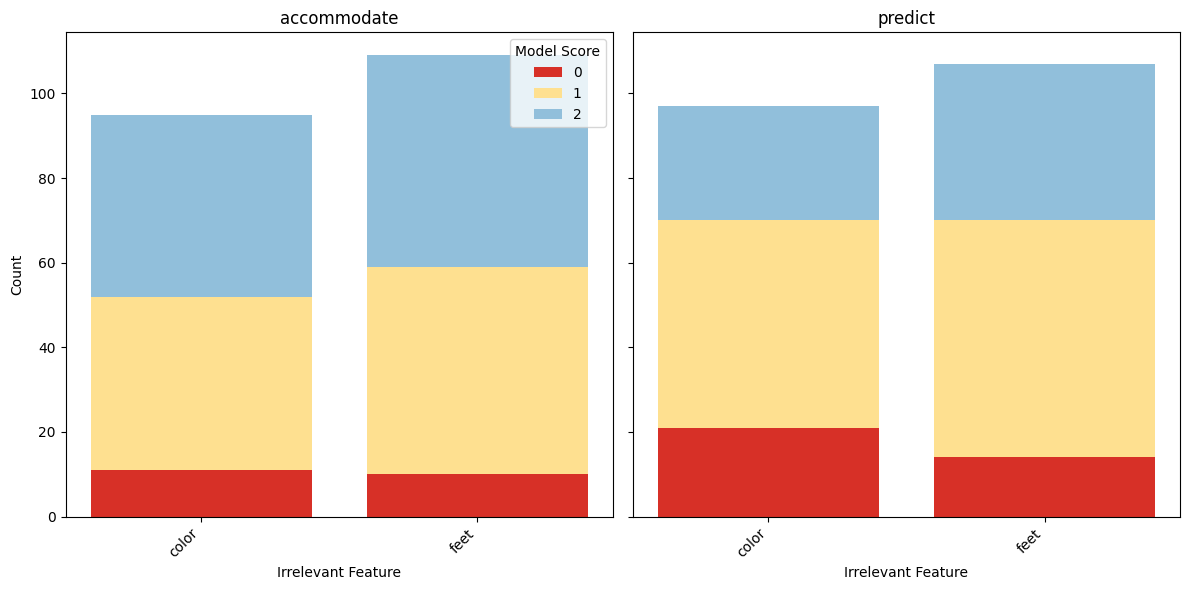

In [413]:
import numpy as np
import matplotlib.pyplot as plt
import os

df_params['task'] = df_params['task'].astype('category')

# Count occurrences of each model_param_score within each task × irrelevant feature
score_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'model_param_score'])
    .size()
    .reset_index(name='count')
)

# Pivot so each score becomes a column
score_pivot = score_counts.pivot_table(
    index=['task', 'irrelevant_dim'],
    columns='model_param_score',
    values='count',
    fill_value=0
).reset_index()

print(score_pivot)

tasks = df_params['task'].cat.categories
buckets = [0, 1, 2]   # now only 3 possible scores with 2 features
colors = ['#d73027', '#fee090', '#91bfdb']  # one color per score

# Create subplots, one per task
fig, axes = plt.subplots(1, len(tasks), figsize=(12, 6), sharey=True)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    # Filter for this task
    task_data = score_pivot[score_pivot['task'] == task].copy()

    x = np.arange(len(task_data))
    bottom = np.zeros(len(task_data))

    for i, b in enumerate(buckets):
        values = task_data[b] if b in task_data.columns else np.zeros(len(task_data))
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=f"{b}" if ax == axes[0] else "",
            color=colors[i]
        )
        bottom += values.values if hasattr(values, "values") else values

    ax.set_xticks(x)
    ax.set_xticklabels(task_data['irrelevant_dim'], rotation=45, ha='right')
    ax.set_title(task)
    ax.set_xlabel("Irrelevant Feature")

axes[0].set_ylabel("Count")
axes[0].legend(title="Model Score")
plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3ModelParamScoreDistributionByTaskAndIrrelevantFeature.png'))
plt.show()

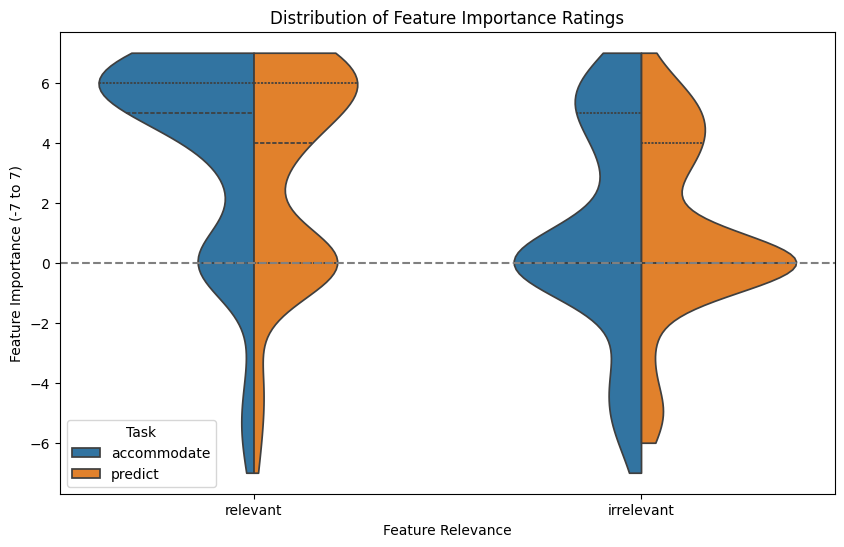

                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         feature_importance
No. Observations:           816             Method:                     REML              
No. Groups:                 408             Scale:                      11.0243           
Min. group size:            2               Log-Likelihood:             -2137.2539        
Max. group size:            2               Converged:                  Yes               
Mean group size:            2.0                                                           
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        3.897    0.232 16.764 0.000  3.441  4.353
task[T.predict]           

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [416]:
import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'color_importance',
    'relevant_dim', 'irrelevant_dim', 'feet_high','color_high', 'feet_discrete_slider.response'
]

df_long = df_filtered[cols_to_keep].copy()

# Melt importance columns
df_long = df_long.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high', 'feet_discrete_slider.response'],
    value_vars=['feet_importance', 'color_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
#plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()
import statsmodels.formula.api as smf

#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['relevant', 'irrelevant'], ordered=False)

model = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())
#model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStats.csv"))


In [409]:
print(df_long)

     participant         task relevant_dim irrelevant_dim color_high  \
0              1  accommodate         feet          color          Y   
1              2  accommodate         feet          color          Y   
2              3  accommodate        color           feet          Y   
3              5  accommodate         feet          color          Y   
4              6  accommodate        color           feet          Y   
..           ...          ...          ...            ...        ...   
811          430      predict        color           feet          Y   
812          431      predict         feet          color          Y   
813          432      predict         feet          color          Y   
814          433      predict        color           feet          Y   
815          434      predict        color           feet          Y   

    feet_high feet_discrete_slider.response feature_dimension  \
0           F                            No              feet   
1    

In [417]:
df_long.to_csv(os.path.join(outputdirCleaned, 'df_long_for_R-Study3Filtered.csv'), index=False)

In [ ]:
import ast
import matplotlib.pyplot as plt
#Calculate reported food amounts during testing
def AverageFoodCalclator(participants_to_use):
    df_subset = df_combined[df_combined['participant'].isin(participants_to_use)]
    all_trials = []
    for i in df_subset['participant']:
        ratings     = df_subset[df_subset['participant'] == i]['testing_responses'].iloc[0]
        categories = df_subset[df_subset['participant'] == i]['testing_categories'].iloc[0]
        task = df_subset[df_subset['participant'] == i]['task'].iloc[0]
        row = df_subset[df_subset['participant'] == i].iloc[0]
        tail_yes  = 1 if row['tail_discrete_slider.response']  == 'Yes' else 0
        shape_yes = 1 if row['shape_discrete_slider.response'] == 'Yes' else 0
        color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0
        num_features_relevant = tail_yes + shape_yes + color_yes
        df_participant = pd.DataFrame(list(zip(
            [i]*len(ratings),  # Repeat participant ID and task to match the number of ratings
            ratings,
            [task]*len(ratings), # Repeat participant ID and task to match the number of ratings
            categories,
            [num_features_relevant]*len(ratings)
        )), columns=['participant', 'ratings', 'task', 'category', 'num_features_relevant'])
        all_trials.append(df_participant)
    df_average = pd.concat(all_trials, ignore_index=True)
    avg_ratings_cond = df_average.groupby(['task', 'category'])['ratings'].mean()
    return df_average, avg_ratings_cond

participants_to_use = df_combined['participant'].tolist()
df_average, avg_rating_cond = AverageFoodCalclator(participants_to_use)
print(avg_rating_cond)
print(df_average)
# Group by task, category, and num_features_relevant
model_parameter_score = df_average.groupby(
    ['num_features_relevant']
)['ratings'].mean().reset_index()

print(model_parameter_score)
# Group by task, category, and num_features_relevant
avg_ratings_cond_by_relevance = df_average.groupby(
    ['task', 'category', 'num_features_relevant']
)['ratings'].mean().reset_index()


print(avg_ratings_cond_by_relevance)
category_order = ['low', 'medium', 'high']
avg_ratings_cond_by_relevance['category'] = pd.Categorical(
    avg_ratings_cond_by_relevance['category'],
    categories=category_order,
    ordered=True
)
import seaborn as sns
sns.catplot(
    data=avg_ratings_cond_by_relevance,
    x='category', y='ratings',
    hue='num_features_relevant', col='task',
    kind='bar', palette='Set2'
)
plt.show()

<Axes: xlabel='category', ylabel='ratings'>

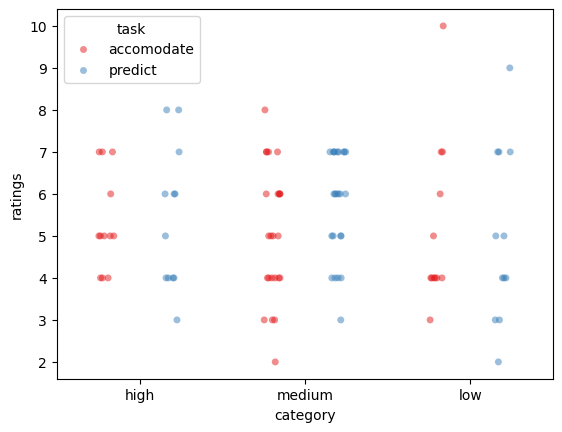

In [ ]:
sns.stripplot(data=df_average, x='category', y='ratings', hue='task', 
              palette='Set1', dodge=True, jitter=True, color='black', alpha=0.5)

In [ ]:
print(df_average.head(20))

    participant  ratings        task category  num_features_relevant
0             1      6.0  accomodate     high                      1
1             1      5.0  accomodate   medium                      1
2             1      3.0  accomodate      low                      1
3             1      5.0  accomodate   medium                      1
4             1      5.0  accomodate   medium                      1
5             1      7.0  accomodate     high                      1
6             1      4.0  accomodate      low                      1
7             1      4.0  accomodate   medium                      1
8             2      5.0  accomodate   medium                      2
9             2      3.0  accomodate   medium                      2
10            2      5.0  accomodate     high                      2
11            2      7.0  accomodate      low                      2
12            2      7.0  accomodate     high                      2
13            2      5.0  accomoda

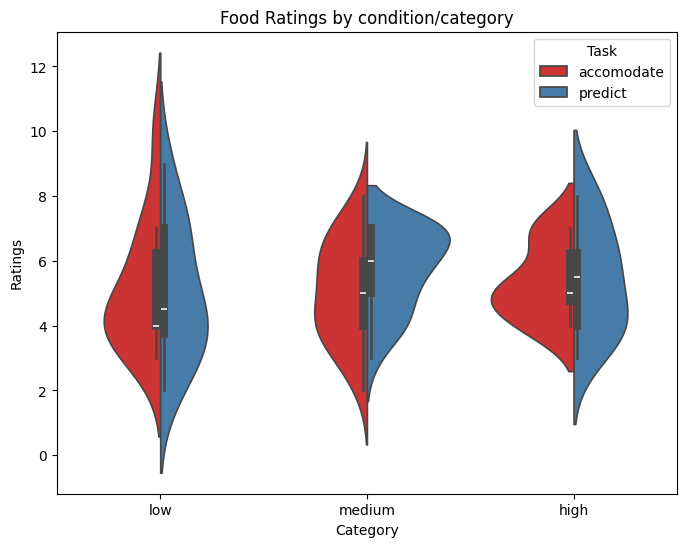

In [ ]:
order = ['low', 'medium', 'high']
# Violin plot: ratings by category, separated by task
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df_average,
    x='category',       # x-axis: categories
    y='ratings',        # y-axis: ratings
    hue='task',         # split by task
    split=True,         # split the violins by task
    palette='Set1',
    inner='box',    # show box plot of data inside
    order = order
)

plt.ylabel('Ratings')
plt.xlabel('Category')
plt.title('Food Ratings by condition/category')
plt.legend(title='Task')
#plt.savefig(f'{study}Plots/ViolinRatings.png', bbox_inches='tight')
plt.show()

In [ ]:
def decode_rel(rel_values):
    """
    rel_values: Series of lists of rel codes
    """

    flat_vals = []
    for v in rel_values:
        if isinstance(v, list):
            flat_vals.extend(v)

    flat_vals = pd.Series(flat_vals).dropna().unique()

    if len(flat_vals) == 0:
        return pd.Series({'feature_relevance': np.nan})

    # irrelevant: only I-codes
    if all(v.startswith('I') for v in flat_vals):
        return pd.Series({'feature_relevance': 'irrelevant'})

    # relevant: contains R or L
    if any(v.startswith(('R', 'L')) for v in flat_vals):
        return pd.Series({'feature_relevance': 'relevant'})

    raise ValueError(f"Unexpected rel codes: {flat_vals}")


feature_relevance_rows = []

for (cond, task), subdf in df_combined.groupby(['conditionOrder', 'task']):
    for feat in ['tail', 'color', 'shape']:
        relevance = decode_rel(subdf[f'training_{feat}'])

        feature_relevance_rows.append({
            'conditionOrder': cond,
            'task': task,
            'feature_dimension': feat,
            'feature_relevance': relevance
        })

df_feature_relevance = pd.DataFrame(feature_relevance_rows)
print(df_feature_relevance)

    conditionOrder        task feature_dimension  \
0                1  accomodate              tail   
1                1  accomodate             color   
2                1  accomodate             shape   
3                1     predict              tail   
4                1     predict             color   
5                1     predict             shape   
6                2  accomodate              tail   
7                2  accomodate             color   
8                2  accomodate             shape   
9                2     predict              tail   
10               2     predict             color   
11               2     predict             shape   
12               3  accomodate              tail   
13               3  accomodate             color   
14               3  accomodate             shape   
15               3     predict              tail   
16               3     predict             color   
17               3     predict             shape   
18          

In [ ]:
features = ['shape', 'color', 'tail']
long_rows = []

for _, row in df_combined.iterrows():
    for feat in features:
        long_rows.append({
            'participant': row['participant'],
            'conditionOrder': row['conditionOrder'],
            'task': row['task'],
            'feature_dimension': feat,

            'discrete': row[f'{feat}_discrete_slider.response'],
            'direction': row[f'{feat}_direction_slider.response'],
            'continuous': row[f'{feat}_continuous_slider.response'],
        })

df_long = pd.DataFrame(long_rows)
print(df_long.head(10))

   participant  conditionOrder        task feature_dimension discrete  \
0            1               4  accomodate             shape      Yes   
1            1               4  accomodate             color       No   
2            1               4  accomodate              tail       No   
3            2               1  accomodate             shape       No   
4            2               1  accomodate             color      Yes   
5            2               1  accomodate              tail      Yes   
6            3               3  accomodate             shape      Yes   
7            3               3  accomodate             color      Yes   
8            3               3  accomodate              tail      Yes   
9            4               2  accomodate             shape      Yes   

       direction  continuous  
0         Square         5.0  
1            NaN         NaN  
2            NaN         NaN  
3            NaN         NaN  
4           Blue         4.0  
5  Having 

In [ ]:
df_long = df_long.merge(
    df_feature_relevance,
    on=['conditionOrder', 'task', 'feature_dimension'],
    how='left'
)
print(df_long.head(21))

    participant  conditionOrder        task feature_dimension discrete  \
0             1               4  accomodate             shape      Yes   
1             1               4  accomodate             color       No   
2             1               4  accomodate              tail       No   
3             2               1  accomodate             shape       No   
4             2               1  accomodate             color      Yes   
5             2               1  accomodate              tail      Yes   
6             3               3  accomodate             shape      Yes   
7             3               3  accomodate             color      Yes   
8             3               3  accomodate              tail      Yes   
9             4               2  accomodate             shape      Yes   
10            4               2  accomodate             color      Yes   
11            4               2  accomodate              tail      Yes   
12            5               2     pr